# **Project Name**    - FitPulse: Smart Device Usage Intelligence for Bellabeat (Strava Fitness Data Analytics)

##### **Project Type**    - EDA
##### **Contribution**    - Individual
##### **Member -** Adarsh Shrikant Tiwari

# **Project Summary -**

Bellabeat makes smart wellness products for women: the Leaf tracker, the Time watch, the Spring water bottle and the Bellabeat app. Co-founder and Chief Creative Officer Urška Sršen believes that understanding how people use existing fitness trackers can open new growth opportunities. This project studies one month of Fitbit data (the "Strava Fitness" dataset) from 33 users to find usage patterns and turn them into marketing recommendations for the Bellabeat app and Leaf tracker.

The dataset has 18 CSV files (about 430 MB) at daily, hourly, minute and 5-second level, covering 12 April to 12 May 2016. Instead of working only with the small daily files, this project builds a layered **DuckDB warehouse**. All 18 files are landed as compressed parquet (16 MB), then processed by four SQL layers: staging (type casting and date parsing with `strptime`), cleaning (rule-based, with an audit log), marts (fact and dimension tables), and analysis queries. This made it possible to use the full 2.48 million heart-rate readings and the 188,000 minute-level sleep records, which produced two measures the daily files do not contain: **bedtime** and **resting heart rate**.

The cleaning rules follow good research practice. A day is valid only if the tracker recorded steps and at least 10 hours of wear, which is the standard accelerometer wear-time rule. The partial last day was removed. Duplicate sleep nights (11) and sleep minutes (543) were removed. Impossible heart-rate values were filtered out, and the mostly empty Fat column was dropped. A reconciliation check proved that the dailySteps and dailyCalories files match dailyActivity exactly (0 mismatches in 940 rows), so they could be excluded safely. After cleaning, the analysis uses 840 valid user-days, 402 nights and 21,840 user-hours.

Users were also grouped into four behavioural personas with **K-Means clustering** on five features: Performance Seekers, Everyday Movers, Desk-Bound Sitters and Drifting Users. Key findings were checked with statistical tests (t-test, ANOVA, Kruskal-Wallis, Pearson and Spearman).

The 22 charts follow the UBM rule. The main insights are:
- A valid day averages 8,443 steps. Only 36% of days reach 10k, and 79% of tracked minutes are sedentary.
- Movement is strongly timed: weekdays peak at 5-7 PM, weekends at 12-2 PM, and heart rate confirms the 6 PM peak.
- Intensity drives energy: very active minutes predict calories (r = 0.62) better than steps (0.55).
- Sleep averages 6.98 hours and 44.5% of nights are under 7 hours. Nights starting after 12:30 AM average only 5.95 hours, 1.5 hours less than nights starting before 11 PM (ANOVA p < 0.001).
- More sitting goes with less sleep (r = -0.68).
- Engagement fades: valid wear days fall 17% from week 1 to week 4, and feature adoption falls from activity (100%) to weight logging (24%).
- Low-activity users are also the least consistent wearers.

The recommendations for Bellabeat are time-aware nudges, a bedtime coach, a combined "sit less, sleep better" campaign, short high-intensity sessions, persona-based journeys, and zero-effort tracking with streak protection. They are prioritised on an impact-effort matrix with a 90-day roadmap in the accompanying Streamlit app.

The whole project is reproducible: SQL files, a Python build pipeline, this notebook (runs top to bottom without errors), and a nine-page Streamlit application with an interactive dashboard, SQL workbench and statistical lab. The main limitations are the small sample, no demographic data and the 2016 date.

# **GitHub Link -**

https://github.com/adarsh-tiwari29/fitpulse-analytics

# **Problem Statement**

**Bellabeat wants to grow in the global smart-device market, but its marketing team does not know how people actually use fitness trackers day to day: when they move, how intensely, how they sleep, which features they use, and when they lose interest. Using public Fitbit data from 33 users, this project finds these usage patterns and turns them into marketing recommendations for the Bellabeat app and Leaf tracker.**

#### **Define Your Business Objective?**

To find evidence-based trends in smart-device usage (activity timing and intensity, sedentary behaviour, sleep duration and timing, heart rate, feature adoption and engagement over time), to group users into actionable personas, and to turn these into prioritised marketing recommendations that help Bellabeat attract new customers and keep existing users engaged.

**Guiding questions:** (1) What are the trends in smart-device usage? (2) How could they apply to Bellabeat customers? (3) How could they influence Bellabeat's marketing strategy?

**Stakeholders:** Urška Sršen (Co-founder and CCO), Sando Mur (Co-founder, executive team), and the Bellabeat marketing analytics team.

# **General Guidelines** : -

1. Well-structured, formatted and commented code is used throughout.
2. Exception handling is used for data loading and the warehouse build. The notebook runs top to bottom in one go without errors.
3. Every logic step is commented.
4. Every chart answers why it was chosen, what the insight is, and its business impact (positive and negative).
5. 22 charts are created following the UBM rule (Univariate, Bivariate, Multivariate).

# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Import Libraries
import sys
import warnings
from pathlib import Path

import duckdb                        # in-process SQL engine used for all cleaning and modelling
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats              # hypothesis tests

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 40)

# ---- Design tokens shared with the Streamlit app ----
SURFACE, LINE, TEXT, MUTED = "#11171F", "#1E2732", "#E8EEF4", "#7F8D9B"
LIME, SKY, CORAL, VIOLET, AMBER = "#D4FF4F", "#58C4F6", "#FF6A55", "#9D8CFF", "#FFB547"
PERSONA_COLORS = {"Performance Seekers": LIME, "Everyday Movers": SKY, "Desk-Bound Sitters": AMBER, "Drifting Users": CORAL}
WEEK = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

sns.set_theme(style="darkgrid", rc={
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE, "axes.edgecolor": LINE,
    "grid.color": LINE, "text.color": TEXT, "axes.labelcolor": MUTED, "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.titlecolor": TEXT, "axes.titleweight": "bold", "axes.titlesize": 14, "legend.facecolor": SURFACE,
    "legend.edgecolor": LINE, "axes.spines.top": False, "axes.spines.right": False})
print("duckdb", duckdb.__version__, "| pandas", pd.__version__, "| seaborn", sns.__version__)

duckdb 1.5.5 | pandas 3.0.2 | seaborn 0.13.2


### Dataset Loading

In [2]:
# Find the project root (folder containing /sql and /data) so the notebook runs from any location
def find_root() -> Path:
    for folder in [Path.cwd(), *Path.cwd().parents]:
        if (folder / "sql").is_dir() and (folder / "data" / "raw").is_dir():
            return folder
    raise FileNotFoundError("Open this notebook inside the FitPulse project folder.")

ROOT = find_root()
RAW = ROOT / "data" / "raw"
sys.path.insert(0, str(ROOT))

# All 18 original CSV files were landed as parquet (text-typed, exactly as exported) to cut 430 MB to 16 MB
raw_files = sorted(RAW.glob("*.parquet"))
raw = {}
for f in raw_files:
    try:
        raw[f.stem] = duckdb.sql(f"SELECT * FROM read_parquet('{f.as_posix()}')").df()
    except Exception as err:                                    # keep going if one file is damaged
        print(f"Could not read {f.name}: {err}")
print(f"Loaded {len(raw)} raw tables:", ", ".join(raw))

Loaded 18 raw tables: dailyActivity, dailyCalories, dailyIntensities, dailySteps, heartrate_seconds, hourlyCalories, hourlyIntensities, hourlySteps, minuteCaloriesNarrow, minuteCaloriesWide, minuteIntensitiesNarrow, minuteIntensitiesWide, minuteMETsNarrow, minuteSleep, minuteStepsNarrow, minuteStepsWide, sleepDay, weightLogInfo


### Dataset First View

In [3]:
# Dataset First Look - the main daily table
raw["dailyActivity"].head()

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
0,1503960366,4/12/2016,13162,8.5,8.5,0,1.87999999523163,0.550000011920929,6.05999994277954,0,25,13,328,728,1985
1,1503960366,4/13/2016,10735,6.96999979019165,6.96999979019165,0,1.57000005245209,0.689999997615814,4.71000003814697,0,21,19,217,776,1797
2,1503960366,4/14/2016,10460,6.73999977111816,6.73999977111816,0,2.44000005722046,0.400000005960464,3.91000008583069,0,30,11,181,1218,1776
3,1503960366,4/15/2016,9762,6.28000020980835,6.28000020980835,0,2.14000010490417,1.25999999046326,2.82999992370605,0,29,34,209,726,1745
4,1503960366,4/16/2016,12669,8.15999984741211,8.15999984741211,0,2.71000003814697,0.409999996423721,5.03999996185303,0,36,10,221,773,1863


In [4]:
# First look at the sleep, minute-sleep and heart-rate tables
for name in ["sleepDay", "minuteSleep", "heartrate_seconds", "weightLogInfo"]:
    print(f"--- {name} ---"); display(raw[name].head(3))

--- sleepDay ---


,Id,SleepDay,TotalSleepRecords,TotalMinutesAsleep,TotalTimeInBed
0,1503960366,4/12/2016 12:00:00 AM,1,327,346
1,1503960366,4/13/2016 12:00:00 AM,2,384,407
2,1503960366,4/15/2016 12:00:00 AM,1,412,442


--- minuteSleep ---


,Id,date,value,logId
0,1503960366,4/12/2016 2:47:30 AM,3,11380564589
1,1503960366,4/12/2016 2:48:30 AM,2,11380564589
2,1503960366,4/12/2016 2:49:30 AM,1,11380564589


--- heartrate_seconds ---


,Id,Time,Value
0,2022484408,4/12/2016 7:21:00 AM,97
1,2022484408,4/12/2016 7:21:05 AM,102
2,2022484408,4/12/2016 7:21:10 AM,105


--- weightLogInfo ---


,Id,Date,WeightKg,WeightPounds,Fat,BMI,IsManualReport,LogId
0,1503960366,5/2/2016 11:59:59 PM,52.5999984741211,115.963146545323,22,22.6499996185303,True,1462233599000
1,1503960366,5/3/2016 11:59:59 PM,52.5999984741211,115.963146545323,NaN,22.6499996185303,True,1462319999000
2,1927972279,4/13/2016 1:08:52 AM,133.5,294.317120016975,NaN,47.5400009155273,False,1460509732000


### Dataset Rows & Columns count

In [5]:
# Dataset Rows & Columns count for all 18 files
overview = pd.DataFrame({n: {"rows": len(d), "columns": d.shape[1], "users": d["Id"].nunique(),
                              "memory_MB": round(d.memory_usage(deep=True).sum() / 1e6, 1)} for n, d in raw.items()}).T
overview.sort_values("rows", ascending=False)

,rows,columns,users,memory_MB
heartrate_seconds,2483658.0,3.0,14.0,139.3
minuteCaloriesNarrow,1325580.0,3.0,33.0,93.0
minuteStepsNarrow,1325580.0,3.0,33.0,73.0
minuteIntensitiesNarrow,1325580.0,3.0,33.0,72.9
minuteMETsNarrow,1325580.0,3.0,33.0,74.2
minuteSleep,188521.0,4.0,24.0,13.9
hourlySteps,22099.0,3.0,33.0,1.2
hourlyCalories,22099.0,3.0,33.0,1.2
hourlyIntensities,22099.0,4.0,33.0,1.5
minuteIntensitiesWide,21645.0,62.0,33.0,12.7


### Dataset Information

In [6]:
# Dataset Info - every column was landed as text, so types must be cast in SQL staging
raw["dailyActivity"].info()

<class 'pandas.DataFrame'>
RangeIndex: 940 entries, 0 to 939
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Id                        940 non-null    str  
 1   ActivityDate              940 non-null    str  
 2   TotalSteps                940 non-null    str  
 3   TotalDistance             940 non-null    str  
 4   TrackerDistance           940 non-null    str  
 5   LoggedActivitiesDistance  940 non-null    str  
 6   VeryActiveDistance        940 non-null    str  
 7   ModeratelyActiveDistance  940 non-null    str  
 8   LightActiveDistance       940 non-null    str  
 9   SedentaryActiveDistance   940 non-null    str  
 10  VeryActiveMinutes         940 non-null    str  
 11  FairlyActiveMinutes       940 non-null    str  
 12  LightlyActiveMinutes      940 non-null    str  
 13  SedentaryMinutes          940 non-null    str  
 14  Calories                  940 non-null    str  
dtype

#### Duplicate Values

In [7]:
# Dataset Duplicate Value Count per file
dups = pd.Series({n: int(d.duplicated().sum()) for n, d in raw.items()}, name="duplicate_rows")
dups[dups > 0].to_frame() if dups.any() else "No duplicates"

,duplicate_rows
minuteSleep,543
sleepDay,3


#### Missing Values/Null Values

In [8]:
# Missing Values/Null Values Count per file
nulls = pd.Series({n: int(d.isna().sum().sum()) for n, d in raw.items()}, name="null_values")
display(nulls[nulls > 0].to_frame())
raw["weightLogInfo"].isna().sum()

,null_values
weightLogInfo,65


Id                 0
Date               0
WeightKg           0
WeightPounds       0
Fat               65
BMI                0
IsManualReport     0
LogId              0
dtype: int64

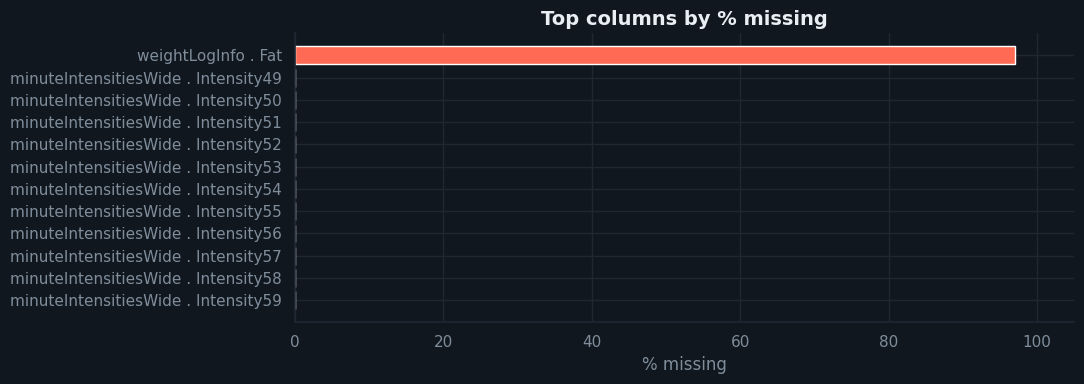

In [9]:
# Visualizing the missing values: % missing per column for the files that have any
miss = pd.concat({n: d.isna().mean() * 100 for n, d in raw.items()}).rename("pct").reset_index()
miss.columns = ["file", "column", "pct"]
fig, ax = plt.subplots(figsize=(11, 4))
top = miss.sort_values("pct", ascending=False).head(12)
ax.barh(top["file"] + " . " + top["column"], top["pct"], color=[CORAL if v > 0 else LINE for v in top["pct"]])
ax.invert_yaxis(); ax.set(title="Top columns by % missing", xlabel="% missing", xlim=(0, 105))
plt.tight_layout(); plt.show()

### What did you know about your dataset?

- There are **18 files**: 4 daily, 3 hourly, 9 minute-level (in narrow and wide formats), 1 at 5-second heart-rate level, and 1 for weight logs. Together they are about 430 MB as CSV.
- **33 users** have activity data, but only **24** have sleep data, **14** have heart-rate data and **8** have weight data.
- All columns were exported as text. Dates use the `M/D/YYYY h:mm:ss AM/PM` format and must be parsed.
- **Duplicates:** sleepDay has 3 and minuteSleep has 543 exact duplicate rows.
- **Missing values:** only the Fat column in weightLogInfo (65 of 67 missing).
- The daily steps, calories and intensities files look like subsets of dailyActivity. This is checked with a reconciliation query.
- There is no demographic information and the distance unit is not documented (assumed km). The last day (12 May) is a partial export.

## ***2. Understanding Your Variables***

In [10]:
# Dataset Columns for each file
for n, d in raw.items():
    print(f"{n:<24} {list(d.columns)}")

dailyActivity            ['Id', 'ActivityDate', 'TotalSteps', 'TotalDistance', 'TrackerDistance', 'LoggedActivitiesDistance', 'VeryActiveDistance', 'ModeratelyActiveDistance', 'LightActiveDistance', 'SedentaryActiveDistance', 'VeryActiveMinutes', 'FairlyActiveMinutes', 'LightlyActiveMinutes', 'SedentaryMinutes', 'Calories']
dailyCalories            ['Id', 'ActivityDay', 'Calories']
dailyIntensities         ['Id', 'ActivityDay', 'SedentaryMinutes', 'LightlyActiveMinutes', 'FairlyActiveMinutes', 'VeryActiveMinutes', 'SedentaryActiveDistance', 'LightActiveDistance', 'ModeratelyActiveDistance', 'VeryActiveDistance']
dailySteps               ['Id', 'ActivityDay', 'StepTotal']
heartrate_seconds        ['Id', 'Time', 'Value']
hourlyCalories           ['Id', 'ActivityHour', 'Calories']
hourlyIntensities        ['Id', 'ActivityHour', 'TotalIntensity', 'AverageIntensity']
hourlySteps              ['Id', 'ActivityHour', 'StepTotal']
minuteCaloriesNarrow     ['Id', 'ActivityMinute', 'Calories']
mi

In [11]:
# Dataset Describe - numeric view of the main table (cast from text for the summary)
raw["dailyActivity"].drop(columns=["Id", "ActivityDate"]).apply(pd.to_numeric).describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
TotalSteps,940.0,7637.91,5087.15,0.0,3789.75,7405.50,10727.00,36019.00
TotalDistance,940.0,5.49,3.92,0.0,2.62,5.24,7.71,28.03
TrackerDistance,940.0,5.48,3.91,0.0,2.62,5.24,7.71,28.03
LoggedActivitiesDistance,940.0,0.11,0.62,0.0,0.00,0.00,0.00,4.94
VeryActiveDistance,940.0,1.50,2.66,0.0,0.00,0.21,2.05,21.92
ModeratelyActiveDistance,940.0,0.57,0.88,0.0,0.00,0.24,0.80,6.48
LightActiveDistance,940.0,3.34,2.04,0.0,1.95,3.36,4.78,10.71
SedentaryActiveDistance,940.0,0.00,0.01,0.0,0.00,0.00,0.00,0.11
VeryActiveMinutes,940.0,21.16,32.84,0.0,0.00,4.00,32.00,210.00
FairlyActiveMinutes,940.0,13.56,19.99,0.0,0.00,6.00,19.00,143.00


### Variables Description

| Table | Key variables | Meaning |
|---|---|---|
| dailyActivity | TotalSteps, TotalDistance, VeryActive/FairlyActive/LightlyActive/SedentaryMinutes, Calories | Daily totals per user |
| sleepDay | TotalSleepRecords, TotalMinutesAsleep, TotalTimeInBed | Daily sleep totals |
| minuteSleep | value (1 asleep, 2 restless, 3 awake), logId | Sleep state each minute; logId groups minutes into a session |
| hourlySteps / Calories / Intensities | StepTotal, Calories, TotalIntensity, AverageIntensity | Hour-level activity |
| heartrate_seconds | Value | Heart rate (bpm) about every 5 seconds |
| weightLogInfo | WeightKg, BMI, Fat, IsManualReport | Weight entries, manual or synced |
| minute* Narrow/Wide | Steps, Calories, Intensity, METs | Minute-level detail of the hourly data |

**Engineered variables (SQL marts):** `is_valid_day` (10-hour wear rule), `active_min`, `tracked_min`, `weekday`, `is_weekend`, `study_week`, `step_band`, `met_30_min_mvpa`, `hours_asleep`, `efficiency_pct`, `sleep_band`, `bedtime_hour` (from minute data), `resting_bpm_est` (5th percentile of daily heart rate), `features_used`, `step_segment`, `engagement_tier` and `persona` (K-Means).

### Check Unique Values for each variable.

In [12]:
# Check Unique Values for each variable in the main files
for n in ["dailyActivity", "sleepDay", "weightLogInfo", "hourlySteps"]:
    print(f"--- {n} ---"); print(raw[n].nunique().to_string(), "\n")

--- dailyActivity ---
Id                           33
ActivityDate                 31
TotalSteps                  842
TotalDistance               615
TrackerDistance             613
LoggedActivitiesDistance     19
VeryActiveDistance          333
ModeratelyActiveDistance    211
LightActiveDistance         491
SedentaryActiveDistance       9
VeryActiveMinutes           122
FairlyActiveMinutes          81
LightlyActiveMinutes        335
SedentaryMinutes            549
Calories                    734 

--- sleepDay ---
Id                     24
SleepDay               31
TotalSleepRecords       3
TotalMinutesAsleep    256
TotalTimeInBed        242 

--- weightLogInfo ---
Id                 8
Date              56
WeightKg          34
WeightPounds      34
Fat                2
BMI               36
IsManualReport     2
LogId             56 

--- hourlySteps ---
Id                33
ActivityHour     736
StepTotal       2222 



## 3. ***Data Wrangling***

### Data Wrangling Code

All wrangling is done in **SQL on DuckDB**, in four layers. The notebook runs each SQL file and then checks the result.

`raw parquet -> 01_staging.sql -> 02_cleaning.sql -> 03_marts.sql -> K-Means personas -> 04_analysis.sql`

In [13]:
# Write your code to make your dataset analysis ready.
# Build the warehouse with the project pipeline (runs the three SQL layers and the persona model)
from pipeline.build_warehouse import build, WAREHOUSE
try:
    build(force=True)                     # re-run every SQL layer from the raw parquet files
except PermissionError:
    # On Windows the file is locked if the Streamlit app is running: reuse the existing warehouse
    print("Warehouse is in use by another process, using the existing build.")
    build(force=False)
except Exception as err:
    raise RuntimeError(f"Warehouse build failed: {err}")
con = duckdb.connect(str(WAREHOUSE), read_only=True)

def sql(q: str) -> pd.DataFrame:
    """Run SQL on the warehouse and return a DataFrame. Errors are printed, not raised."""
    try:
        return con.execute(q).df()
    except Exception as err:
        print("Query failed:", err); return pd.DataFrame()

print("Tables:", ", ".join(sql("SELECT table_name FROM duckdb_tables() ORDER BY 1")["table_name"]))

Tables: cln_daily_activity, cln_heartrate, cln_hourly, cln_minute_sleep, cln_sleep_day, cln_weight, dim_user, dim_user_persona, dq_log, dq_reconciliation, fct_daily, fct_daily_sleep, fct_heartrate_daily, fct_heartrate_hourly, fct_hourly, fct_sleep, fct_sleep_sessions, model_elbow, stg_daily_activity, stg_daily_calories, stg_daily_steps, stg_hourly, stg_sleep_day, stg_weight


In [14]:
# Show an excerpt of the staging SQL: typed casting and strptime date parsing
print((ROOT / "sql" / "01_staging.sql").read_text()[:1500])

-- =============================================================================
-- LAYER 1 : STAGING
-- Engine  : DuckDB
-- Purpose : Read the raw landing files (all columns stored as text, exactly as
--           exported by Fitabase) and cast every column to the correct type.
--           No rows are removed here. Staging = typed copy of raw.
-- Params  : {raw} is replaced by the raw folder path at build time.
-- =============================================================================

CREATE OR REPLACE TABLE stg_daily_activity AS
SELECT
    CAST(Id AS BIGINT)                                   AS user_id,
    CAST(strptime(ActivityDate, '%m/%d/%Y') AS DATE)     AS activity_date,
    CAST(TotalSteps AS INTEGER)                          AS steps,
    CAST(TotalDistance AS DOUBLE)                        AS distance_km,
    CAST(TrackerDistance AS DOUBLE)                      AS tracker_distance_km,
    CAST(LoggedActivitiesDistance AS DOUBLE)             AS logged_distance_km,
   

In [15]:
# Cleaning audit log: every rule and its effect on row counts
sql("SELECT * FROM dq_log ORDER BY step")

,step,rule,table_name,rows_before,rows_after,note
0,01,R5 partial last day removed,daily_activity,940,919,Export ended part-way through 12 May 2016
1,02,R2 wear-time flag,daily_activity,919,840,Days with 0 steps or < 10 h tracked are flagge...
2,03,R1 duplicates removed,sleep_day,413,402,Exact duplicate nights removed
3,04,R1 duplicates removed,minute_sleep,188521,187978,Exact duplicate minutes removed
4,05,R5 partial last day removed,hourly,22099,21840,"Steps, calories and intensity joined into one ..."
5,06,R3 impossible bpm removed,heartrate,2483658,2462068,Readings outside 30-220 bpm and the partial la...
6,07,R4 Fat column dropped,weight,67,67,65 of 67 Fat values were missing


In [16]:
# Reconciliation: prove the daily sub-files are exact copies of dailyActivity columns
sql("SELECT * FROM dq_reconciliation")

,check_name,rows_compared,mismatches
0,dailySteps vs dailyActivity,940,0
1,dailyCalories vs dailyActivity,940,0


In [17]:
# Load the analysis-ready marts into pandas
daily_all   = sql("SELECT * FROM fct_daily")                           # all days, with is_valid_day flag
daily       = daily_all[daily_all["is_valid_day"]].copy()              # valid days only
sleep       = sql("SELECT * FROM fct_sleep")
daily_sleep = sql("SELECT * FROM fct_daily_sleep")
hourly      = sql("SELECT * FROM fct_hourly")
hr_hourly   = sql("SELECT * FROM fct_heartrate_hourly")
users       = sql("SELECT u.*, p.persona FROM dim_user u JOIN dim_user_persona p USING (user_id)")

# Sanity checks: the cleaning rules really hold
assert daily["steps"].gt(0).all() and daily["tracked_min"].ge(600).all()
assert not sleep.duplicated(["user_id", "sleep_date"]).any()
assert hourly["hour_of_day"].between(0, 23).all()
print(f"valid days {len(daily)} | nights {len(sleep)} | activity+sleep {len(daily_sleep)} | "
      f"user-hours {len(hourly)} | users {len(users)}")
daily.head()

valid days 840 | nights 402 | activity+sleep 397 | user-hours 21840 | users 33


,user_id,activity_date,steps,distance_km,tracker_distance_km,logged_distance_km,very_active_km,moderate_km,light_km,sedentary_km,very_active_min,fairly_active_min,lightly_active_min,sedentary_min,calories,active_min,tracked_min,is_valid_day,weekday,weekday_num,is_weekend,study_week,step_band,met_30_min_mvpa
0,1503960366,2016-04-12,13162,8.50,8.50,0.0,1.88,0.55,6.06,0.0,25,13,328,728,1985,366,1094,True,Tuesday,2,False,1,4 10k+,True
1,1503960366,2016-04-13,10735,6.97,6.97,0.0,1.57,0.69,4.71,0.0,21,19,217,776,1797,257,1033,True,Wednesday,3,False,1,4 10k+,True
2,1503960366,2016-04-14,10460,6.74,6.74,0.0,2.44,0.40,3.91,0.0,30,11,181,1218,1776,222,1440,True,Thursday,4,False,1,4 10k+,True
3,1503960366,2016-04-15,9762,6.28,6.28,0.0,2.14,1.26,2.83,0.0,29,34,209,726,1745,272,998,True,Friday,5,False,1,3 7.5k-10k,True
4,1503960366,2016-04-16,12669,8.16,8.16,0.0,2.71,0.41,5.04,0.0,36,10,221,773,1863,267,1040,True,Saturday,6,True,1,4 10k+,True


In [18]:
# SQL insight: overall KPIs on valid days
sql("""
SELECT count(DISTINCT user_id) users, count(*) valid_days, round(avg(steps)) avg_steps,
       round(avg(sedentary_min)/60, 1) sedentary_h, round(avg(very_active_min + fairly_active_min), 1) mvpa_min,
       round(100*avg((steps >= 10000)::INT), 1) pct_10k
FROM fct_daily WHERE is_valid_day
""")

,users,valid_days,avg_steps,sedentary_h,mvpa_min,pct_10k
0,33,840,8443.0,16.2,38.6,36.1


In [19]:
# SQL insight: personas discovered by K-Means
sql("""
SELECT persona, count(*) users, round(avg(avg_steps)) steps, round(avg(avg_mvpa_min),1) mvpa,
       round(avg(avg_sedentary_min)/60,1) sitting_h, round(avg(valid_days),1) wear_days
FROM dim_user JOIN dim_user_persona USING (user_id) GROUP BY 1 ORDER BY steps DESC
""")

,persona,users,steps,mvpa,sitting_h,wear_days
0,Performance Seekers,10,11785.0,74.1,15.3,28.9
1,Everyday Movers,8,8108.0,22.5,12.2,27.1
2,Desk-Bound Sitters,8,6790.0,18.6,19.5,28.0
3,Drifting Users,7,4067.0,16.2,19.3,15.7


### What all manipulations have you done and insights you found?

**Manipulations**
1. **Landing:** all 18 CSVs were stored as zstd parquet with every column as text, so the raw data is preserved exactly (430 MB to 16 MB).
2. **Staging (SQL):** every column cast to the correct type, dates parsed with `strptime('%m/%d/%Y %I:%M:%S %p')`, and the three hourly files joined into one table.
3. **Cleaning (SQL), each rule logged in `dq_log`:**
   - R1: removed exact duplicates (11 sleep nights, 543 sleep minutes).
   - R2: 10-hour wear rule. Days with 0 steps or under 600 tracked minutes are flagged invalid (79 of 919 days) and excluded from behaviour metrics, but kept for engagement analysis.
   - R3: heart-rate readings outside 30-220 bpm removed.
   - R4: Fat column dropped (97% missing).
   - R5: partial last day (12 May) removed.
   - R6: reconciliation, where dailySteps and dailyCalories match dailyActivity with 0 mismatches.
4. **Marts (SQL):** `fct_daily` (calendar fields, step bands, a 30-minute MVPA flag), `fct_sleep_sessions` built from minute data (bedtime, wake time, restless minutes), `fct_sleep` (bands, efficiency, main-session bedtime), `fct_hourly`, heart-rate hourly and daily tables (resting heart rate as the 5th percentile), `fct_daily_sleep` and `dim_user`.
5. **Modelling (Python):** K-Means (k = 4, standardised features, elbow checked) wrote `dim_user_persona` back to the warehouse.

**Insights found during wrangling**
- 8.6% of days fail the wear-time rule, so non-wear is common and must be handled.
- The daily sub-files are proven redundant.
- The average main sleep session starts at about 11:45 PM, and 37% start after midnight. This is only visible from minute-level data.
- Estimated resting heart rate across users is about 60 bpm (range 49-77).

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

### **U - Univariate Analysis**

#### Chart - 1 - Daily Steps: Distribution and Spread  *(Univariate)*

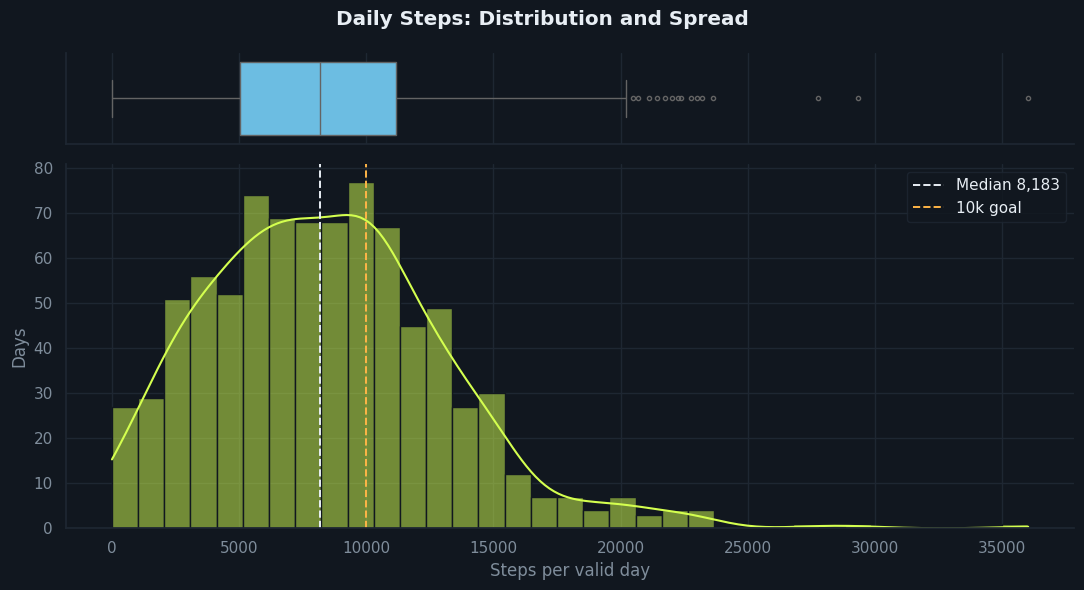

In [20]:
# Chart - 1 visualization code
fig, (ax_box, ax) = plt.subplots(2, 1, figsize=(11, 6), sharex=True, gridspec_kw=dict(height_ratios=[1, 4]))
sns.boxplot(x=daily["steps"], color=SKY, ax=ax_box, fliersize=3)
sns.histplot(daily["steps"], bins=35, kde=True, color=LIME, edgecolor=SURFACE, ax=ax)
for x, lbl, c in [(daily["steps"].median(), f"Median {daily['steps'].median():,.0f}", TEXT), (10000, "10k goal", AMBER)]:
    ax.axvline(x, color=c, ls="--", lw=1.4, label=lbl)
ax_box.set(xlabel=""); ax.set(xlabel="Steps per valid day", ylabel="Days")
ax.legend(); fig.suptitle("Daily Steps: Distribution and Spread", fontweight="bold")
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A boxplot stacked on a histogram shows the full shape of the distribution and its outliers in one view. The median and 10k lines turn the chart into a comparison against a well-known target.

##### 2. What is/are the insight(s) found from the chart?

On valid days the median is 8,183 steps (mean 8,443, standard deviation 4,729). The distribution is right-skewed with outliers up to 36,019. 24.8% of days stay under 5,000 steps and 36.1% reach 10,000.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: the typical user is only about 1,800 steps short of 10k, which is a realistic nudge target for the Bellabeat app. Negative: one day in four is under 5,000 steps. Marketing built only around 10k achievers would push away the low-activity group, who are the users most likely to stop wearing the device.

#### Chart - 2 - Nightly Sleep Duration  *(Univariate)*

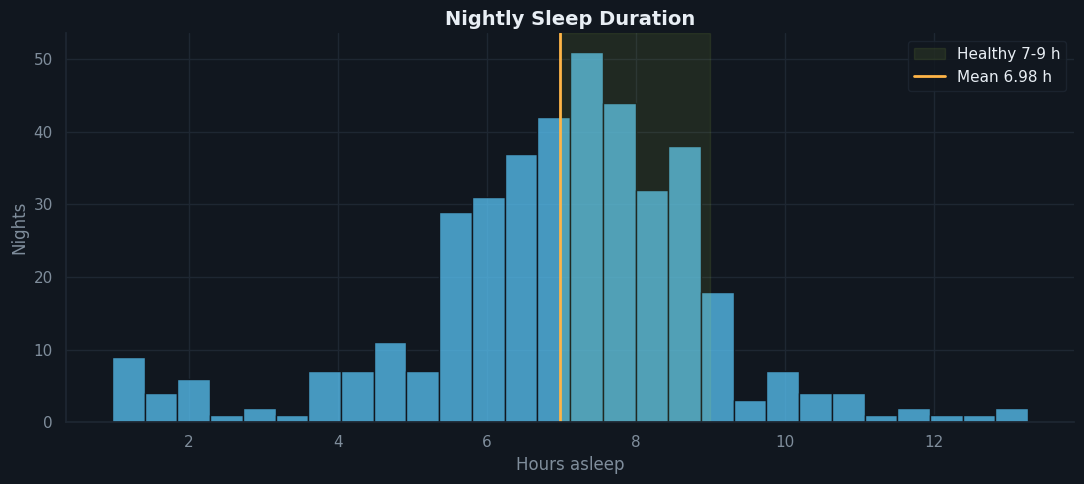

In [21]:
# Chart - 2 visualization code
fig, ax = plt.subplots(figsize=(11, 5))
sns.histplot(sleep["hours_asleep"], bins=28, color=SKY, edgecolor=SURFACE, ax=ax)
ax.axvspan(7, 9, color=LIME, alpha=0.08, label="Healthy 7-9 h")
ax.axvline(sleep["hours_asleep"].mean(), color=AMBER, lw=2, label=f"Mean {sleep['hours_asleep'].mean():.2f} h")
ax.set(title="Nightly Sleep Duration", xlabel="Hours asleep", ylabel="Nights"); ax.legend()
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Sleep duration is a continuous variable with a clear healthy range. Shading that range shows at once how many nights fall inside or outside it.

##### 2. What is/are the insight(s) found from the chart?

The average night is 6.98 hours. Only 45.8% of nights are in the 7-9 hour band, 24.6% are under 6 hours, and 9.7% go over 9 hours.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: almost half the nights are short, which gives Bellabeat a clear sleep-coaching story for Leaf and Time. Negative: only 24 of 33 users logged sleep. If the device is uncomfortable to wear at night, the sleep features will never reach the users who need them most.

#### Chart - 3 - When Does the Main Sleep Session Start?  *(Univariate)*

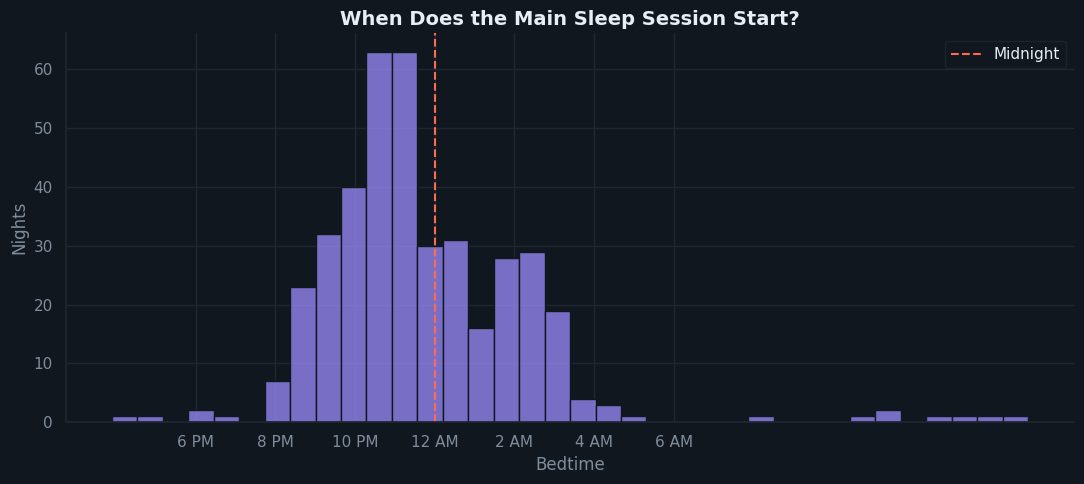

In [22]:
# Chart - 3 visualization code
bt = sleep["bedtime_hour"].dropna()
fig, ax = plt.subplots(figsize=(11, 5))
sns.histplot(bt, bins=36, color=VIOLET, edgecolor=SURFACE, ax=ax)
ax.axvline(24, color=CORAL, ls="--", lw=1.5, label="Midnight")
ticks = [18, 20, 22, 24, 26, 28, 30]
ax.set_xticks(ticks, ["6 PM", "8 PM", "10 PM", "12 AM", "2 AM", "4 AM", "6 AM"])
ax.set(title="When Does the Main Sleep Session Start?", xlabel="Bedtime", ylabel="Nights"); ax.legend()
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Bedtime was derived from minute-level sleep data, which the standard daily file does not provide. A histogram on a continuous clock axis (where 24 means midnight and 26 means 2 AM) shows the spread of bedtimes without splitting at midnight.

##### 2. What is/are the insight(s) found from the chart?

The median bedtime is about 11:15 PM, and half of all sessions start between 10:10 PM and 1:05 AM. 37.3% of main sleep sessions start after midnight, and one in ten starts after 2:30 AM.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: a large group already goes to bed around 10-11 PM, so a 10:30 PM wind-down reminder fits most users' routine. Negative: more than a third of nights begin after midnight. As Chart 12 shows, late starts cost the most sleep, and without an intervention these users will stay short on sleep.

#### Chart - 4 - Estimated Resting Heart Rate per User  *(Univariate)*

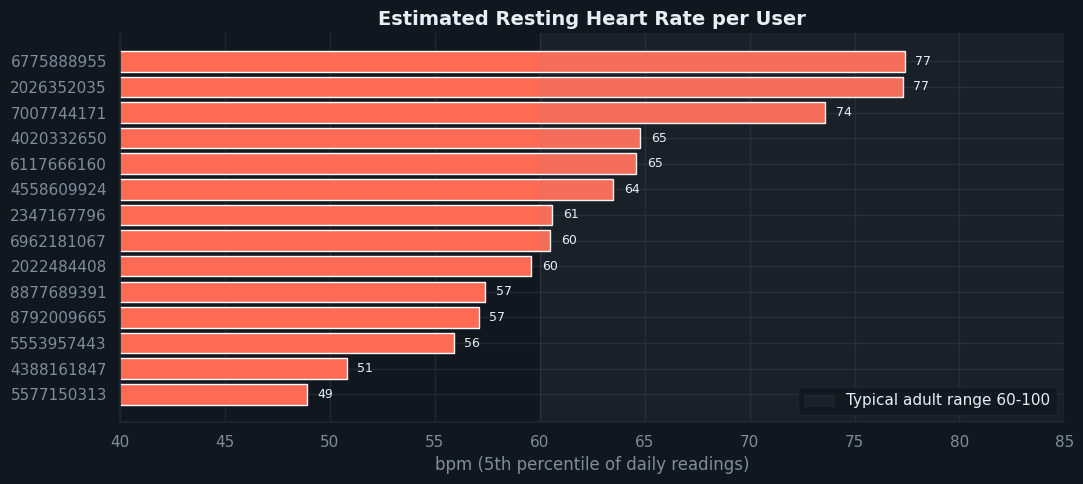

In [23]:
# Chart - 4 visualization code
rh = users.dropna(subset=["resting_bpm"]).sort_values("resting_bpm")
fig, ax = plt.subplots(figsize=(11, 5))
ax.barh(rh["user_id"].astype(str), rh["resting_bpm"], color=CORAL)
ax.axvspan(60, 100, color=MUTED, alpha=0.08, label="Typical adult range 60-100")
for y, v in enumerate(rh["resting_bpm"]):
    ax.text(v + 0.5, y, f"{v:.0f}", va="center", fontsize=9, color=TEXT)
ax.set(title="Estimated Resting Heart Rate per User", xlabel="bpm (5th percentile of daily readings)", ylabel="", xlim=(40, 85))
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Resting heart rate is a strong wellness metric. It was estimated from 2.46 million 5-second readings as the 5th percentile of each day. A sorted horizontal bar per user shows the spread across the 14 users who wore the device with heart rate on.

##### 2. What is/are the insight(s) found from the chart?

Estimated resting heart rate ranges from 48.9 to 77.4 bpm, with a median of about 60.5 bpm. Several users sit below 60 bpm, which is typical of fitter people.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: resting heart rate is easy to understand and changes slowly with fitness, so it is ideal for a monthly "your heart is getting fitter" story in the app. Negative: only 14 of 33 users produced heart-rate data. A headline metric that most users never see cannot drive engagement.

#### Chart - 5 - How Consistently Do Users Wear the Device?  *(Univariate)*

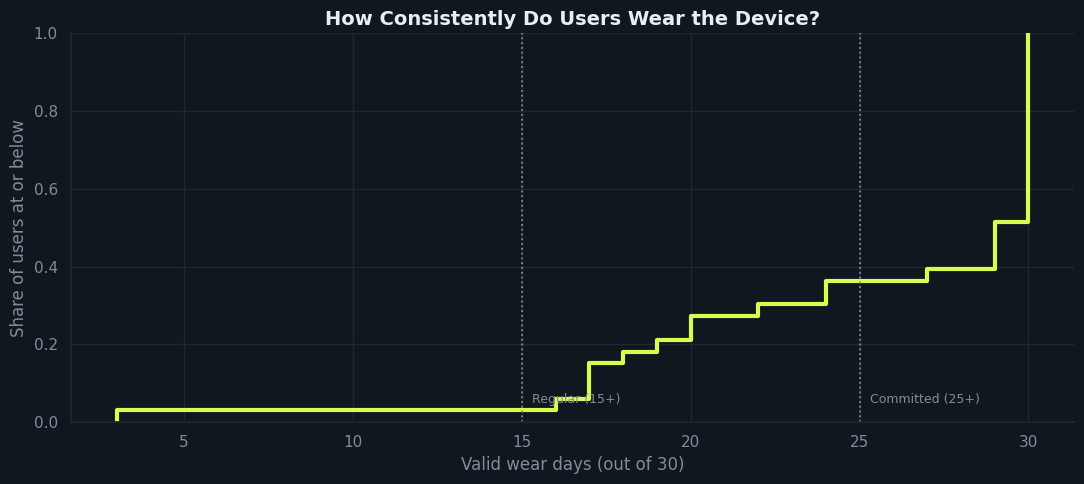

In [24]:
# Chart - 5 visualization code
fig, ax = plt.subplots(figsize=(11, 5))
sns.ecdfplot(users["valid_days"], color=LIME, lw=3, ax=ax)
for x, lbl in [(15, "Regular (15+)"), (25, "Committed (25+)")]:
    ax.axvline(x, color=MUTED, ls=":", lw=1.3)
    ax.text(x + 0.3, 0.05, lbl, color=MUTED, fontsize=9)
ax.set(title="How Consistently Do Users Wear the Device?", xlabel="Valid wear days (out of 30)",
       ylabel="Share of users at or below")
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

An ECDF (empirical cumulative distribution) shows the share of users at or below each number of wear days. It avoids the arbitrary bin choice of a histogram and makes thresholds such as 15 and 25 days easy to read.

##### 2. What is/are the insight(s) found from the chart?

Half of the users have 29 or more valid days, and 16 users have all 30. Only 1 user drops out early (3 days). 21 users (64%) are Committed (25+ days) and 11 are Regular (15-24 days).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: once a user adopts the device the habit is strong, which is a good base for a paid membership. Negative: one third of users miss at least 6 days in a month. Every gap weakens the habit, so the app needs streaks and gentle re-engagement before the gaps grow.

#### Chart - 6 - Nights by Sleep-Duration Band  *(Univariate)*

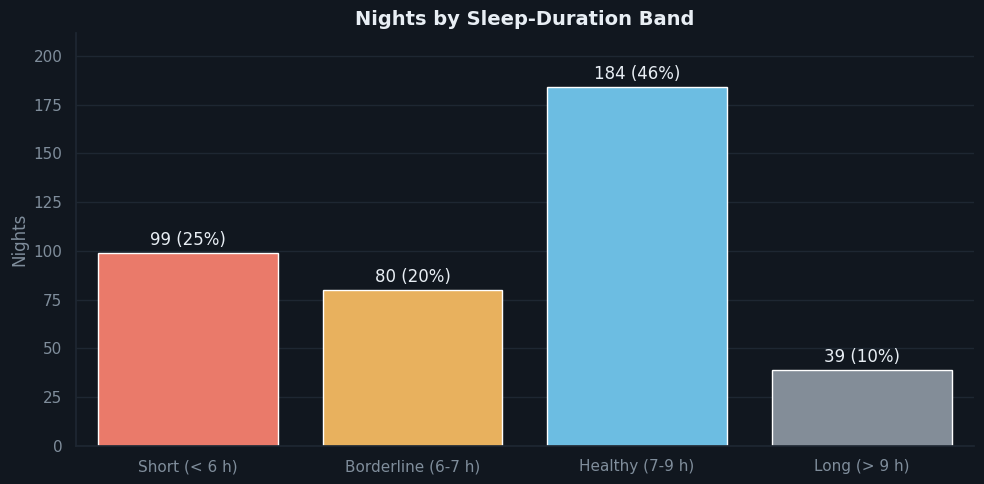

In [25]:
# Chart - 6 visualization code
order = ["Short (< 6 h)", "Borderline (6-7 h)", "Healthy (7-9 h)", "Long (> 9 h)"]
fig, ax = plt.subplots(figsize=(10, 5))
sns.countplot(data=sleep, x="sleep_band", order=order, hue="sleep_band", hue_order=order, legend=False,
              palette=[CORAL, AMBER, SKY, MUTED], ax=ax)
for p in ax.patches:
    ax.annotate(f"{p.get_height():.0f} ({p.get_height()/len(sleep):.0%})", (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom", color=TEXT, xytext=(0, 3), textcoords="offset points")
ax.set(title="Nights by Sleep-Duration Band", xlabel="", ylabel="Nights", ylim=(0, sleep["sleep_band"].value_counts().max() * 1.15))
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Converting sleep hours into clinical bands turns a number into a category that stakeholders can act on. A count plot with percentages shows how nights are split between the bands.

##### 2. What is/are the insight(s) found from the chart?

184 nights (46%) are healthy, 80 (20%) are borderline at 6-7 hours, 99 (25%) are short at under 6 hours, and 39 (10%) are long at over 9 hours.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: the borderline group is only minutes away from healthy sleep, so small bedtime changes would move many nights into the healthy band. Negative: a quarter of nights under 6 hours is a real health risk, and those users are likely to feel tired and move less the next day, which slowly reduces engagement.

### **B - Bivariate Analysis**

#### Chart - 7 - Daily Steps by Weekday  *(Bivariate (Categorical - Numerical))*

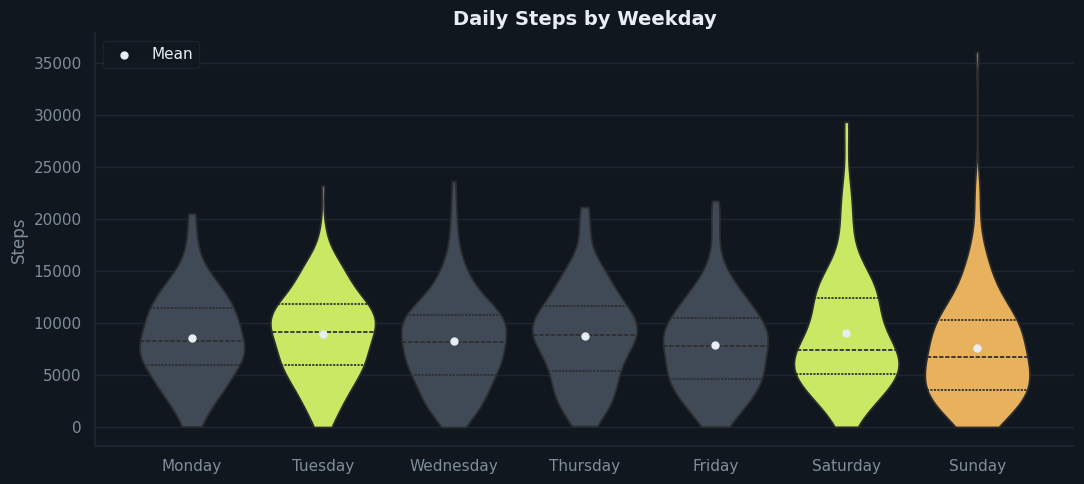

In [26]:
# Chart - 7 visualization code
fig, ax = plt.subplots(figsize=(11, 5))
sns.violinplot(data=daily, x="weekday", y="steps", order=WEEK, hue="weekday", hue_order=WEEK, legend=False,
               palette=[LIME if d in ("Tuesday", "Saturday") else (AMBER if d == "Sunday" else "#3B4A5A") for d in WEEK],
               inner="quartile", cut=0, ax=ax)
means = daily.groupby("weekday")["steps"].mean().reindex(WEEK)
ax.scatter(range(7), means.values, color=TEXT, zorder=5, s=25, label="Mean")
ax.set(title="Daily Steps by Weekday", xlabel="", ylabel="Steps"); ax.legend()
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A violin plot shows the full distribution for each weekday, not just the average, so it is clear whether a difference comes from the whole group or from a few outliers.

##### 2. What is/are the insight(s) found from the chart?

Saturday (9,061) and Tuesday (8,949) have the highest means, and Sunday (7,627) and Friday (7,886) the lowest. A Welch t-test shows no significant difference between weekdays and weekends overall, so the pattern is about individual days, especially Sunday.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: Sunday is a clear target for challenges and social features, for example a "Sunday reset walk". Negative: a weekly rest day can grow into a habit of doing nothing. Without a nudge the Sunday dip can spread to the rest of the week.

#### Chart - 8 - Intraday Movement: Weekday vs Weekend  *(Bivariate (Numerical - Numerical))*

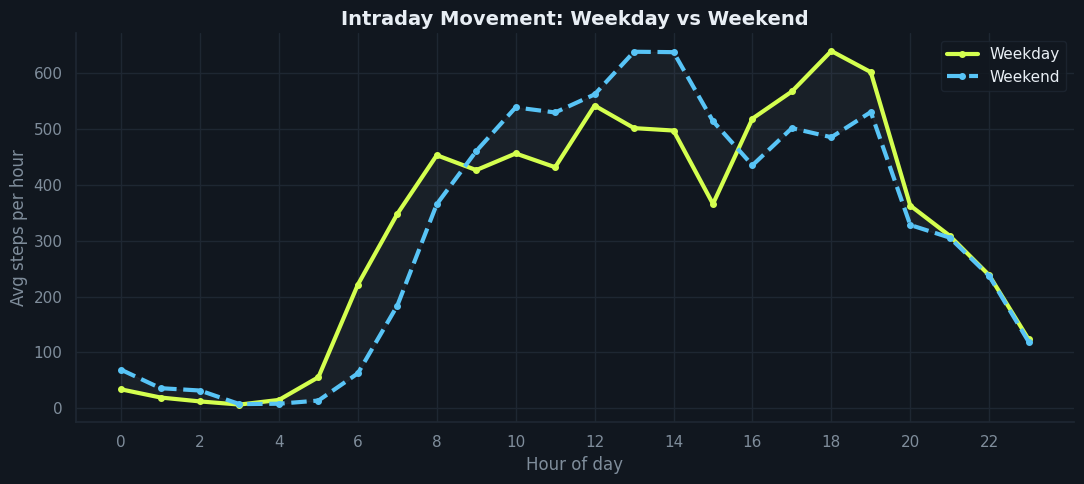

In [27]:
# Chart - 8 visualization code
hw = hourly.groupby(["hour_of_day", "is_weekend"])["steps"].mean().unstack()
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(hw.index, hw[False], color=LIME, lw=3, marker="o", ms=4, label="Weekday")
ax.plot(hw.index, hw[True], color=SKY, lw=3, ls="--", marker="o", ms=4, label="Weekend")
ax.fill_between(hw.index, hw[False], hw[True], color=MUTED, alpha=0.08)
ax.set(title="Intraday Movement: Weekday vs Weekend", xlabel="Hour of day", ylabel="Avg steps per hour", xticks=range(0, 24, 2))
ax.legend()
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Two lines on the same hour axis show how the shape of the day changes between weekdays and weekends. The shaded gap highlights the hours where behaviour differs most.

##### 2. What is/are the insight(s) found from the chart?

Weekdays start at 6-7 AM and peak after work (5-7 PM, about 600 steps an hour). Weekend mornings start about two hours later, and the weekend peak moves to 12-2 PM.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: this supports calendar-aware reminders, with evening prompts on weekdays and late-morning prompts at weekends, which should get higher response rates. Negative: a single fixed reminder time would reach weekend users while they are still asleep, and badly timed alerts are a common reason people turn notifications off.

#### Chart - 9 - Heart Rate Through the Day  *(Bivariate (Numerical - Numerical))*

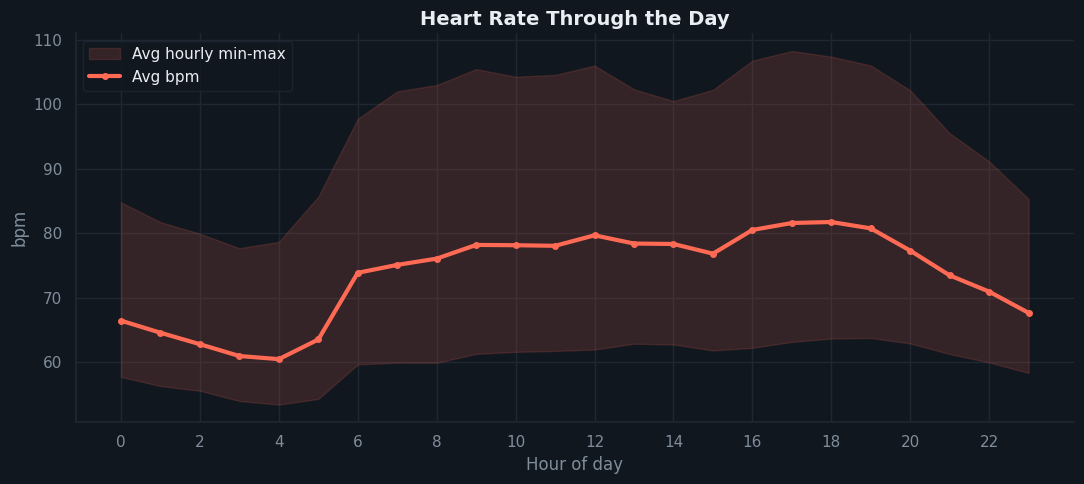

In [28]:
# Chart - 9 visualization code
hp = hr_hourly.groupby("hour_of_day").agg(bpm=("avg_bpm", "mean"), lo=("min_bpm", "mean"), hi=("max_bpm", "mean"))
fig, ax = plt.subplots(figsize=(11, 5))
ax.fill_between(hp.index, hp["lo"], hp["hi"], color=CORAL, alpha=0.15, label="Avg hourly min-max")
ax.plot(hp.index, hp["bpm"], color=CORAL, lw=3, marker="o", ms=4, label="Avg bpm")
ax.set(title="Heart Rate Through the Day", xlabel="Hour of day", ylabel="bpm", xticks=range(0, 24, 2)); ax.legend()
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A line with a min-max band shows both the typical heart rate and its range at each hour. It is an independent sensor that can confirm or challenge the step-based activity pattern.

##### 2. What is/are the insight(s) found from the chart?

Heart rate is lowest at 4 AM (60.5 bpm) and peaks at 6 PM (81.8 bpm), the same hour as the step peak. The band widens in the afternoon and evening, when workouts happen.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: two independent sensors agree on the evening activity window, which makes it a reliable base for campaign timing. Negative: heart-rate data covers only 14 users, so heart-rate features should not be marketed as the main value until more users wear the device with the sensor on.

#### Chart - 10 - What Drives Calorie Burn?  *(Bivariate (Numerical - Numerical))*

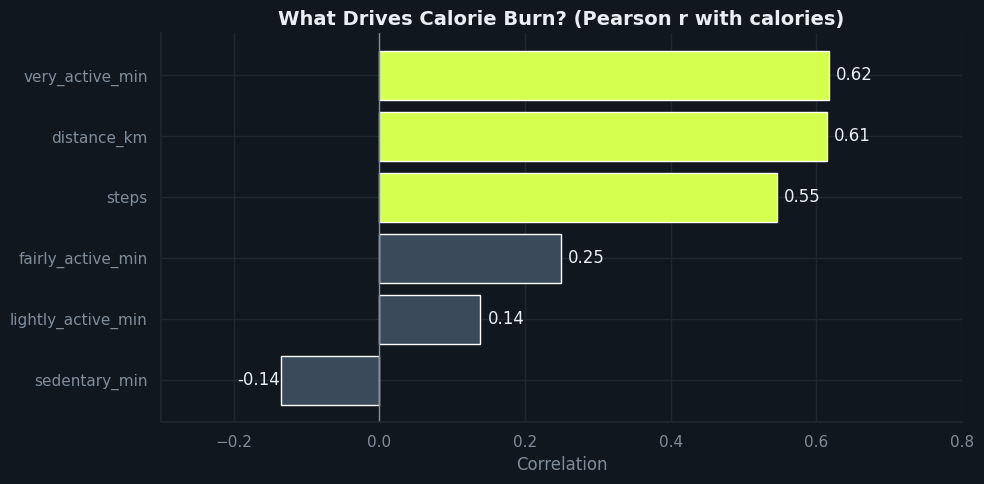

In [29]:
# Chart - 10 visualization code
metrics = ["very_active_min", "distance_km", "steps", "fairly_active_min", "lightly_active_min", "sedentary_min"]
r = daily[metrics].corrwith(daily["calories"]).sort_values()
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(r.index, r.values, color=[LIME if v > 0.5 else "#3B4A5A" for v in r.values])
for y, v in enumerate(r.values):
    ax.text(v + (0.01 if v >= 0 else -0.06), y, f"{v:.2f}", va="center", color=TEXT)
ax.axvline(0, color=MUTED, lw=1)
ax.set(title="What Drives Calorie Burn? (Pearson r with calories)", xlabel="Correlation", xlim=(-0.3, 0.8))
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A ranked bar chart of correlation coefficients compares several numerical predictors of calories at once, which is clearer than six separate scatter plots.

##### 2. What is/are the insight(s) found from the chart?

Very active minutes (r = 0.62) and distance (0.61) are the strongest drivers, ahead of steps (0.55). Fairly active (0.25) and lightly active minutes (0.14) have little effect, and sedentary minutes are slightly negative.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: intensity matters more than volume, so short high-intensity sessions give users visible results fast, which is a strong message for busy women. Negative: most users spend almost no time at high intensity. Promoting step counts alone would push users toward the activity that changes calorie burn the least.

#### Chart - 11 - Very Active Minutes vs Calories  *(Bivariate (Numerical - Numerical))*

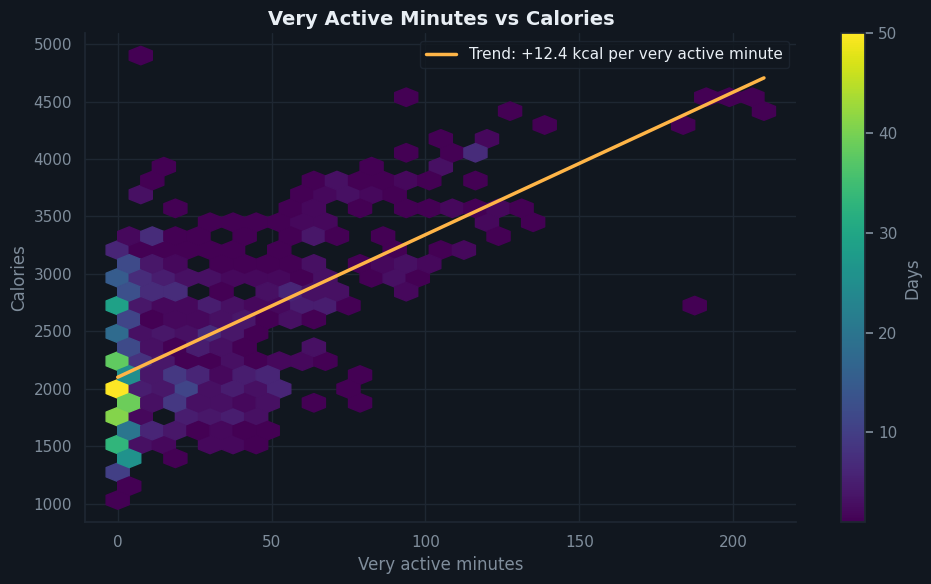

In [30]:
# Chart - 11 visualization code
fig, ax = plt.subplots(figsize=(10, 6))
hb = ax.hexbin(daily["very_active_min"], daily["calories"], gridsize=28, cmap="viridis", mincnt=1)
m, c = np.polyfit(daily["very_active_min"], daily["calories"], 1)
xs = np.linspace(0, daily["very_active_min"].max(), 50)
ax.plot(xs, m * xs + c, color=AMBER, lw=2.5, label=f"Trend: +{m:.1f} kcal per very active minute")
fig.colorbar(hb, ax=ax, label="Days")
ax.set(title="Very Active Minutes vs Calories", xlabel="Very active minutes", ylabel="Calories"); ax.legend()
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A hexbin plot handles overlapping points better than a scatter plot. It shows where the 840 days are concentrated, and the fitted line gives a simple rate that is easy to explain.

##### 2. What is/are the insight(s) found from the chart?

Most days are packed at 0-10 very active minutes. Each extra very active minute adds roughly 12 kcal on the trend line, so 20 minutes is worth about 250 extra calories.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: "20 minutes, 250 calories" is a simple, concrete promise for Bellabeat's workout content. Negative: the dense cluster at zero shows that most days have no vigorous activity at all. The message has to lower the barrier to starting, not just celebrate people who already train.

#### Chart - 12 - Sleep Duration by Bedtime Window  *(Bivariate (Categorical - Numerical))*

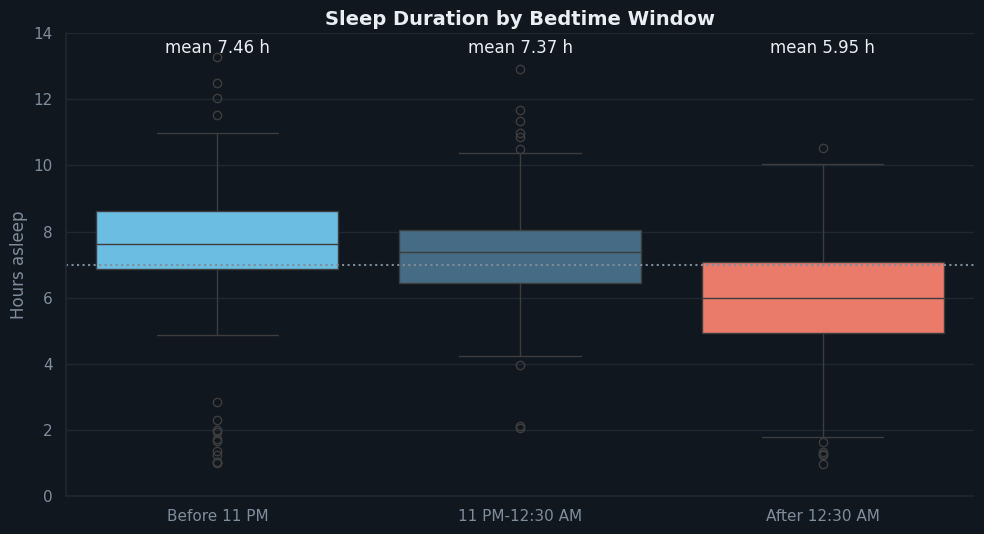

In [31]:
# Chart - 12 visualization code
sl = sleep.dropna(subset=["bedtime_hour"]).copy()
sl["window"] = np.select([sl["bedtime_hour"] < 23, sl["bedtime_hour"] < 24.5], ["Before 11 PM", "11 PM-12:30 AM"], "After 12:30 AM")
order = ["Before 11 PM", "11 PM-12:30 AM", "After 12:30 AM"]
fig, ax = plt.subplots(figsize=(10, 5.5))
sns.boxplot(data=sl, x="window", y="hours_asleep", order=order, hue="window", hue_order=order, legend=False,
            palette=[SKY, "#3B6E8F", CORAL], ax=ax)
ax.axhline(7, color=MUTED, ls=":")
for i, w in enumerate(order):
    ax.text(i, 13.4, f"mean {sl.loc[sl.window == w, 'hours_asleep'].mean():.2f} h", ha="center", color=TEXT)
ax.set(title="Sleep Duration by Bedtime Window", xlabel="", ylabel="Hours asleep", ylim=(0, 14))
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Bedtime window is categorical and sleep hours are numerical, so a box plot per window compares both the medians and the spread. It tests a clear hypothesis: does going to bed late cost sleep?

##### 2. What is/are the insight(s) found from the chart?

Nights starting before 11 PM average 7.46 hours and nights starting between 11 PM and 12:30 AM average 7.37 hours. Nights starting after 12:30 AM drop to 5.95 hours with lower efficiency (88.6% against about 93%). A one-way ANOVA confirms the difference is significant (p < 0.001).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: this gives Bellabeat one clear, testable intervention: get users into bed before 12:30 AM. A wind-down reminder is cheap to build and easy to measure. Negative: late sleepers lose about 1.5 hours a night. If the product only reports sleep without helping change bedtime, these users will see bad scores every day and may stop tracking.

#### Chart - 13 - Sedentary Time vs Same-Night Sleep  *(Bivariate (Numerical - Numerical))*

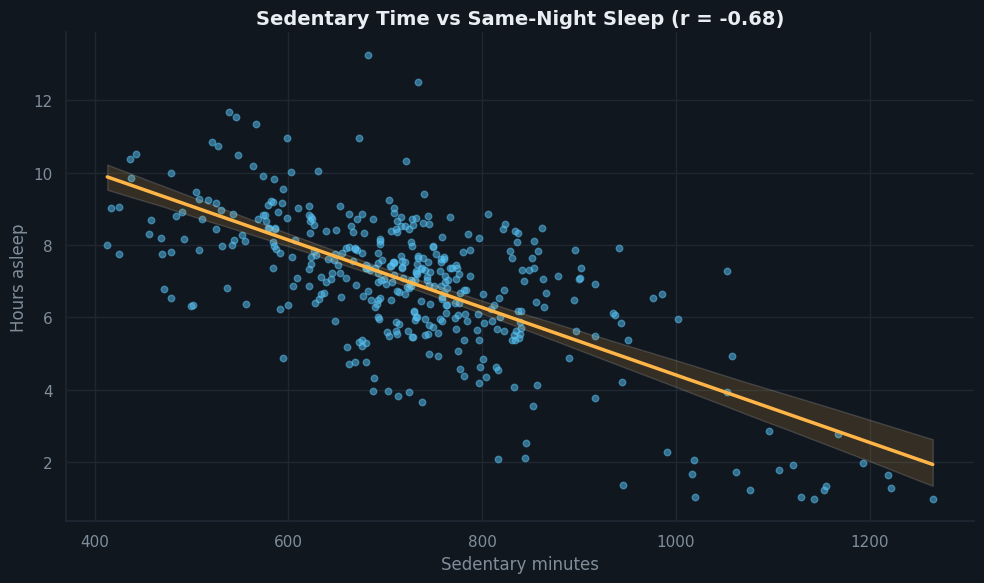

In [32]:
# Chart - 13 visualization code
fig, ax = plt.subplots(figsize=(10, 6))
sns.regplot(data=daily_sleep, x="sedentary_min", y="hours_asleep", scatter_kws=dict(alpha=0.5, s=22, color=SKY),
            line_kws=dict(color=AMBER, lw=2.5), ax=ax)
r = daily_sleep["sedentary_min"].corr(daily_sleep["hours_asleep"])
ax.set(title=f"Sedentary Time vs Same-Night Sleep (r = {r:.2f})", xlabel="Sedentary minutes", ylabel="Hours asleep")
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot with a regression line tests whether sitting time is related to sleep, using only the 397 days that have both activity and sleep data.

##### 2. What is/are the insight(s) found from the chart?

The relationship is strongly negative (r = -0.68). Days with under 10 hours of sitting come with 8.7 hours of sleep, while days with more than 13 hours of sitting come with only 5.4 hours.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: it links two product features into one message, "move more, sleep better", which encourages users to wear the device both day and night. Negative: part of the link is mechanical, because Fitbit does not count sleep minutes as sedentary. Presenting it as medical cause and effect would be misleading and could damage credibility.

#### Chart - 14 - Calories and Intensity by Step Band  *(Bivariate (Categorical - Numerical))*

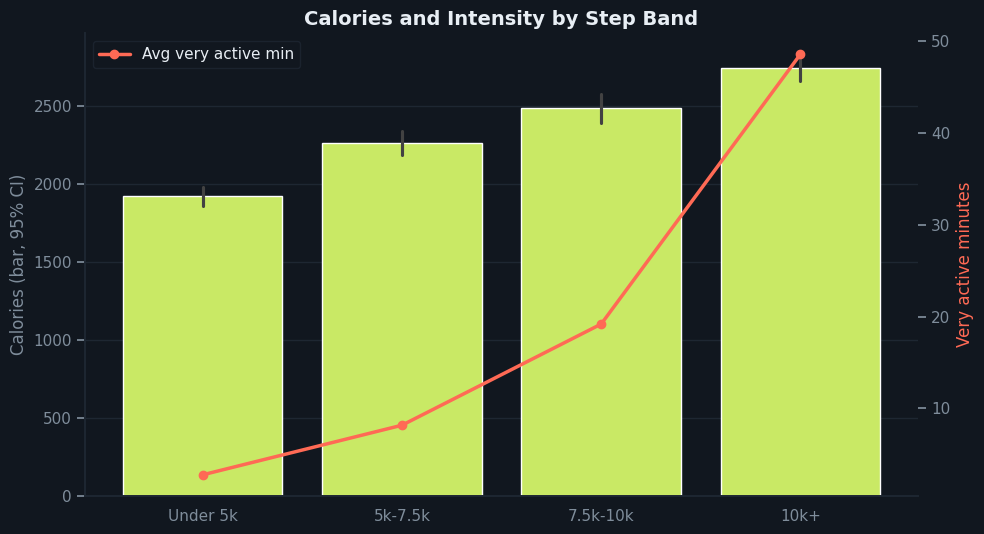

In [33]:
# Chart - 14 visualization code
order = ["1 Under 5k", "2 5k-7.5k", "3 7.5k-10k", "4 10k+"]
fig, ax1 = plt.subplots(figsize=(10, 5.5))
sns.barplot(data=daily, x="step_band", y="calories", order=order, color=LIME, errorbar=("ci", 95), ax=ax1)
ax2 = ax1.twinx()
vm = daily.groupby("step_band")["very_active_min"].mean().reindex(order)
ax2.plot(range(4), vm.values, color=CORAL, marker="o", lw=2.5, label="Avg very active min")
ax2.set_ylabel("Very active minutes", color=CORAL); ax2.grid(False)
ax1.set_xticks(range(4), [o[2:] for o in order])
ax1.set(title="Calories and Intensity by Step Band", xlabel="", ylabel="Calories (bar, 95% CI)"); ax2.legend(loc="upper left")
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Grouping days into step bands (categorical) and comparing mean calories with confidence intervals shows whether the differences are reliable. The second axis shows that intensity rises across the bands as well.

##### 2. What is/are the insight(s) found from the chart?

Calories rise steadily from 1,920 kcal (under 5k) to 2,744 kcal (10k+), a gain of about 820 kcal. Very active minutes rise far more steeply, from 2.8 to 48.5 minutes, so 10k+ days are mainly days that include a real workout.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: the 10k goal works as a proxy for including a workout, which supports goal-based features. Negative: a user who gets 10k steps from slow walking may not see the expected results. The app should reward intensity as well as step count to avoid disappointment.

#### Chart - 15 - Feature Adoption Funnel  *(Bivariate (Categorical - Categorical))*

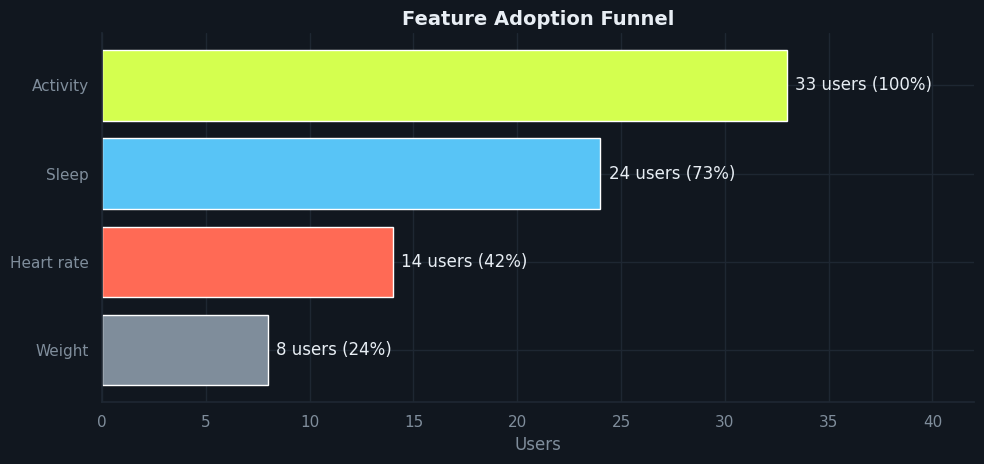

In [34]:
# Chart - 15 visualization code
feat = pd.Series({"Activity": len(users), "Sleep": (users["sleep_nights"] > 0).sum(),
                  "Heart rate": (users["hr_days"] > 0).sum(), "Weight": (users["weight_logs"] > 0).sum()})
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.barh(feat.index[::-1], feat.values[::-1], color=[MUTED, CORAL, SKY, LIME])
for y, v in enumerate(feat.values[::-1]):
    ax.text(v + 0.4, y, f"{v} users ({v/len(users):.0%})", va="center", color=TEXT)
ax.set(title="Feature Adoption Funnel", xlabel="Users", xlim=(0, 42))
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Feature (categorical) against users who used it (a yes/no category, counted) forms a funnel. Horizontal bars ordered from most to least used show where users drop off.

##### 2. What is/are the insight(s) found from the chart?

All 33 users track activity, 24 (73%) track sleep, 14 (42%) record heart rate and 8 (24%) log weight. 61% of weight entries are manual, and only 3 users use all four features.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: activity and sleep are proven hooks and should lead Bellabeat's marketing. Negative: the steep drop for manual or sensor-heavy features shows that friction kills adoption. Promoting features that need effort will not work unless they are automated first.

#### Chart - 16 - Engagement Across the Study  *(Bivariate (Categorical - Numerical))*

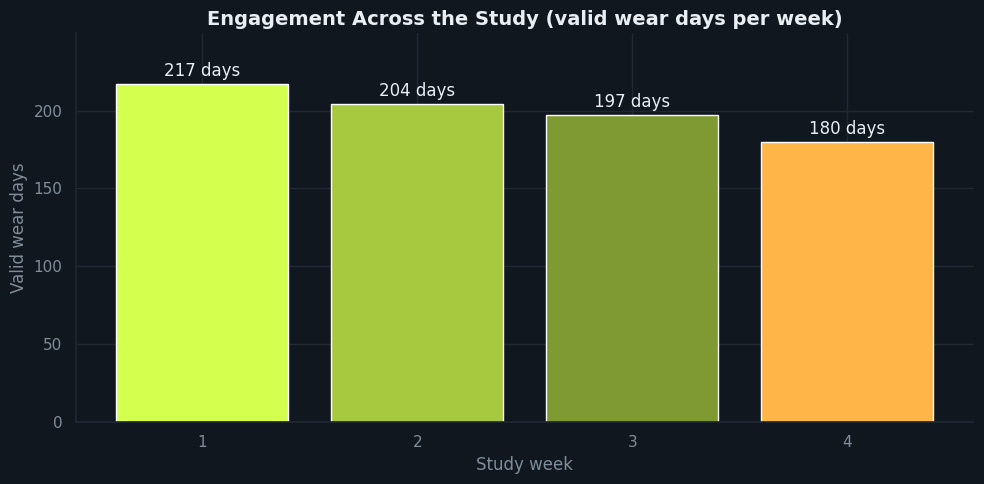

In [35]:
# Chart - 16 visualization code
wk = daily_all[daily_all["study_week"] <= 4].groupby("study_week").agg(valid=("is_valid_day", "sum"),
                                                                        users=("user_id", "nunique"))
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(wk.index.astype(str), wk["valid"], color=[LIME, "#A6C93F", "#7F9A33", AMBER])
ax.bar_label(bars, labels=[f"{v} days" for v in wk["valid"]], color=TEXT, padding=3)
ax.set(title="Engagement Across the Study (valid wear days per week)", xlabel="Study week", ylabel="Valid wear days",
       ylim=(0, wk["valid"].max() * 1.15))
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Study week is an ordered category and valid wear days is a count, so a bar per week shows whether engagement holds up over time. It is the key retention signal in the data.

##### 2. What is/are the insight(s) found from the chart?

Valid wear days fall from 217 in week 1 to 204, 197 and then 180 in week 4, a 17% decline. The number of distinct active users also falls from 33 to 29.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: the decline is gradual, which leaves time to step in during weeks 2-3 with streaks, weekly summaries and challenges. Negative: a steady 17% monthly decay compounds quickly. Without retention features most users would drift away within a few months, which is the biggest commercial risk for a subscription app.

#### Chart - 17 - Engagement Tier vs Step Segment  *(Bivariate (Categorical - Categorical))*

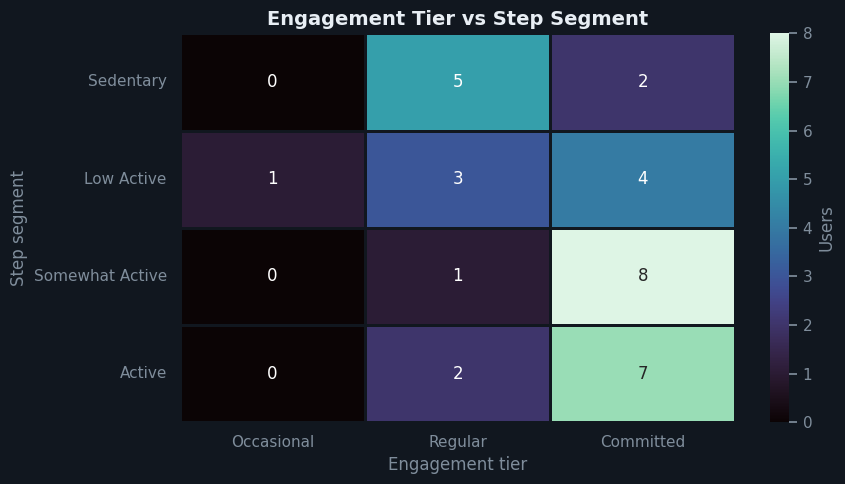

In [36]:
# Chart - 17 visualization code
ct = pd.crosstab(users["step_segment"], users["engagement_tier"]).reindex(
    index=["Sedentary", "Low Active", "Somewhat Active", "Active"], columns=["Occasional", "Regular", "Committed"]).fillna(0)
fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(ct, annot=True, fmt=".0f", cmap="mako", linewidths=1, linecolor=SURFACE, cbar_kws=dict(label="Users"), ax=ax)
ax.set(title="Engagement Tier vs Step Segment", xlabel="Engagement tier", ylabel="Step segment")
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A crosstab heatmap is the standard way to compare two categorical variables. Each cell counts users, so it shows whether activity level and wear consistency go together.

##### 2. What is/are the insight(s) found from the chart?

15 of the 18 Somewhat Active and Active users are Committed wearers. In contrast, 5 of the 7 Sedentary users are only Regular, not Committed. Lower activity goes with less consistent wear.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: active users are loyal users, so they are the best candidates for premium features and referral programs. Negative: the users who would gain the most health benefit are the ones most likely to drift away. Retention efforts should focus on low-activity users first.

### **M - Multivariate Analysis**

#### Chart - 18 - Movement Heatmap: Weekday x Hour  *(Multivariate)*

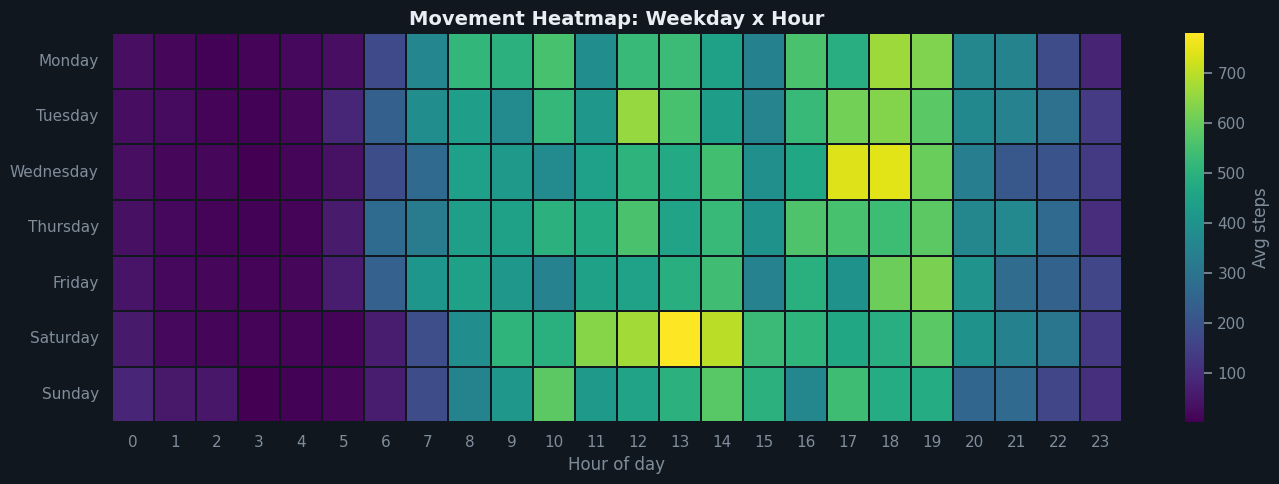

In [37]:
# Chart - 18 visualization code
pv = hourly.pivot_table(index="weekday", columns="hour_of_day", values="steps", aggfunc="mean").reindex(WEEK)
fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(pv, cmap="viridis", linewidths=0.3, linecolor=SURFACE, cbar_kws=dict(label="Avg steps"), ax=ax)
ax.set(title="Movement Heatmap: Weekday x Hour", xlabel="Hour of day", ylabel="")
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A heatmap shows three variables (weekday, hour and steps) at once. It reveals specific hot spots that separate weekday and hourly charts cannot show.

##### 2. What is/are the insight(s) found from the chart?

The brightest cells are Saturday 1 PM (about 780 steps an hour) and Wednesday 5-6 PM (about 740). Weekday mornings light up from 7 AM, and weekend mornings stay dark until about 9 AM.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: Bellabeat can schedule content by exact weekday and hour, for example Saturday lunchtime group walks and Wednesday evening classes, which feels personal at no extra cost. Negative: the dark late-evening and early-morning cells show when users are inactive or asleep. Notifications at those times would be ignored or felt as intrusive.

#### Chart - 19 - Users Mapped by Persona  *(Multivariate)*

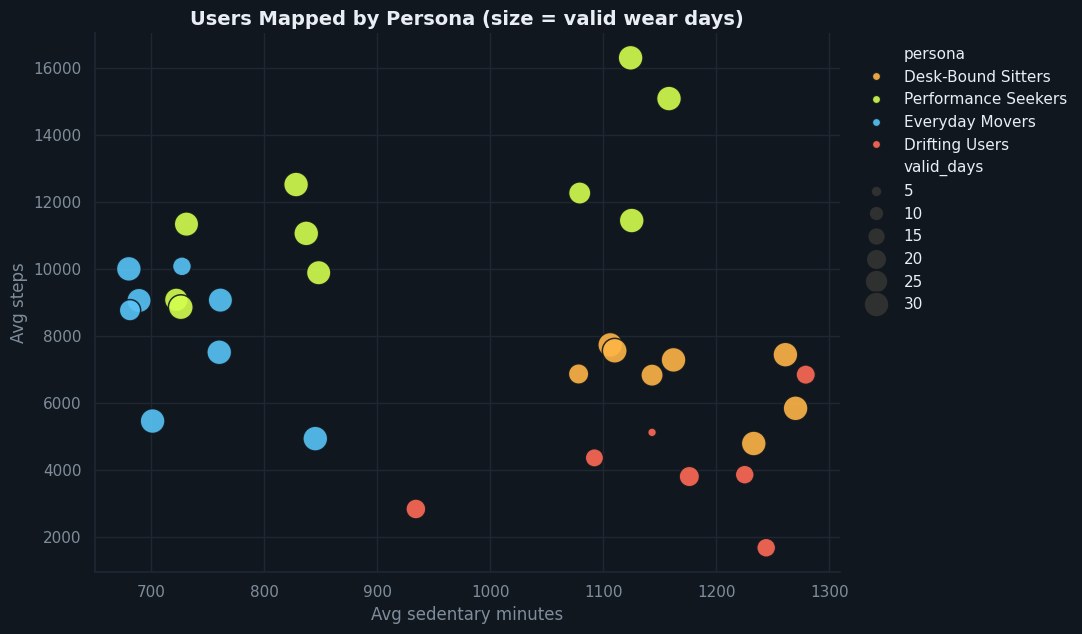

In [38]:
# Chart - 19 visualization code
fig, ax = plt.subplots(figsize=(11, 6.5))
sns.scatterplot(data=users, x="avg_sedentary_min", y="avg_steps", hue="persona", size="valid_days", sizes=(40, 320),
                palette=PERSONA_COLORS, alpha=0.9, edgecolor=SURFACE, ax=ax)
ax.set(title="Users Mapped by Persona (size = valid wear days)", xlabel="Avg sedentary minutes", ylabel="Avg steps")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", frameon=False)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

The scatter uses four variables: sitting time (x), steps (y), persona (colour) and wear days (size). It shows how the K-Means personas sit in behaviour space and whether they separate cleanly.

##### 2. What is/are the insight(s) found from the chart?

Performance Seekers sit at the top (about 11,800 steps). Everyday Movers sit the least (about 12 hours). Desk-Bound Sitters reach about 6,800 steps but sit for 19.5 hours, and Drifting Users are small bubbles (about 16 wear days) in the low-step, high-sitting corner.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: the four groups are visibly distinct, which supports four targeted campaigns and product journeys. Negative: Desk-Bound Sitters walk a moderate amount, so a steps-only view would miss their very long sitting time. That is the kind of hidden risk that simple segmentation overlooks.

#### Chart - 20 - Persona Fingerprint (z-scores)  *(Multivariate)*

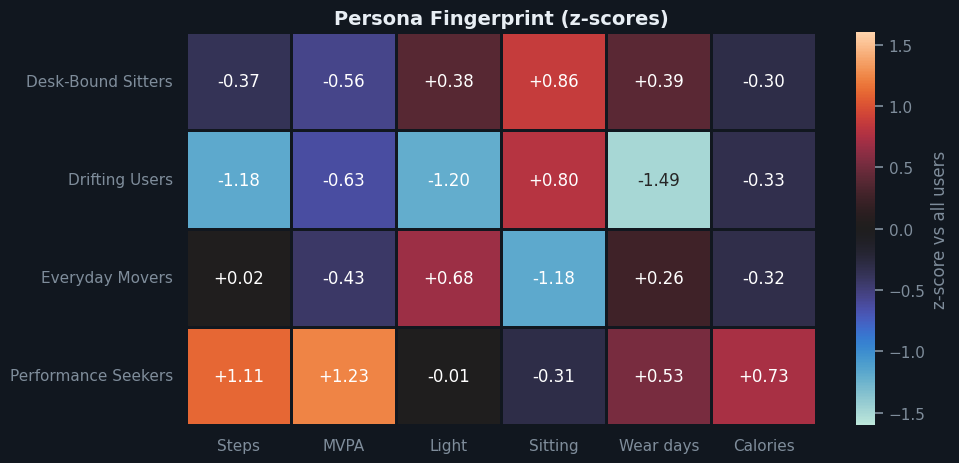

In [39]:
# Chart - 20 visualization code
feats = {"avg_steps": "Steps", "avg_mvpa_min": "MVPA", "avg_light_min": "Light", "avg_sedentary_min": "Sitting",
         "valid_days": "Wear days", "avg_calories": "Calories"}
z = (users[list(feats)] - users[list(feats)].mean()) / users[list(feats)].std()
prof = z.assign(persona=users["persona"]).groupby("persona").mean().rename(columns=feats)
fig, ax = plt.subplots(figsize=(10, 4.8))
sns.heatmap(prof, annot=True, fmt="+.2f", cmap="icefire", center=0, vmin=-1.6, vmax=1.6, linewidths=1,
            linecolor=SURFACE, cbar_kws=dict(label="z-score vs all users"), ax=ax)
ax.set(title="Persona Fingerprint (z-scores)", xlabel="", ylabel="")
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Standardising each feature to z-scores puts steps, minutes and days on the same scale. The heatmap then shows how each persona differs from the average user on every behaviour at once.

##### 2. What is/are the insight(s) found from the chart?

Performance Seekers are well above average on steps (+1.11), MVPA (+1.23) and calories (+0.73). Drifting Users are well below on steps (-1.18) and wear days (-1.49). Everyday Movers are average on steps but lowest on sitting, and Desk-Bound Sitters combine slightly low activity with high sitting.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Positive: each persona has a clear marker that marketing can target (performance, habit, sitting or retention). Negative: Drifting Users are low on everything. They are the most expensive group to win back and could take up budget without results if they are not clearly prioritised.

#### Chart - 21 - Correlation Heatmap  *(Correlation Heatmap)*

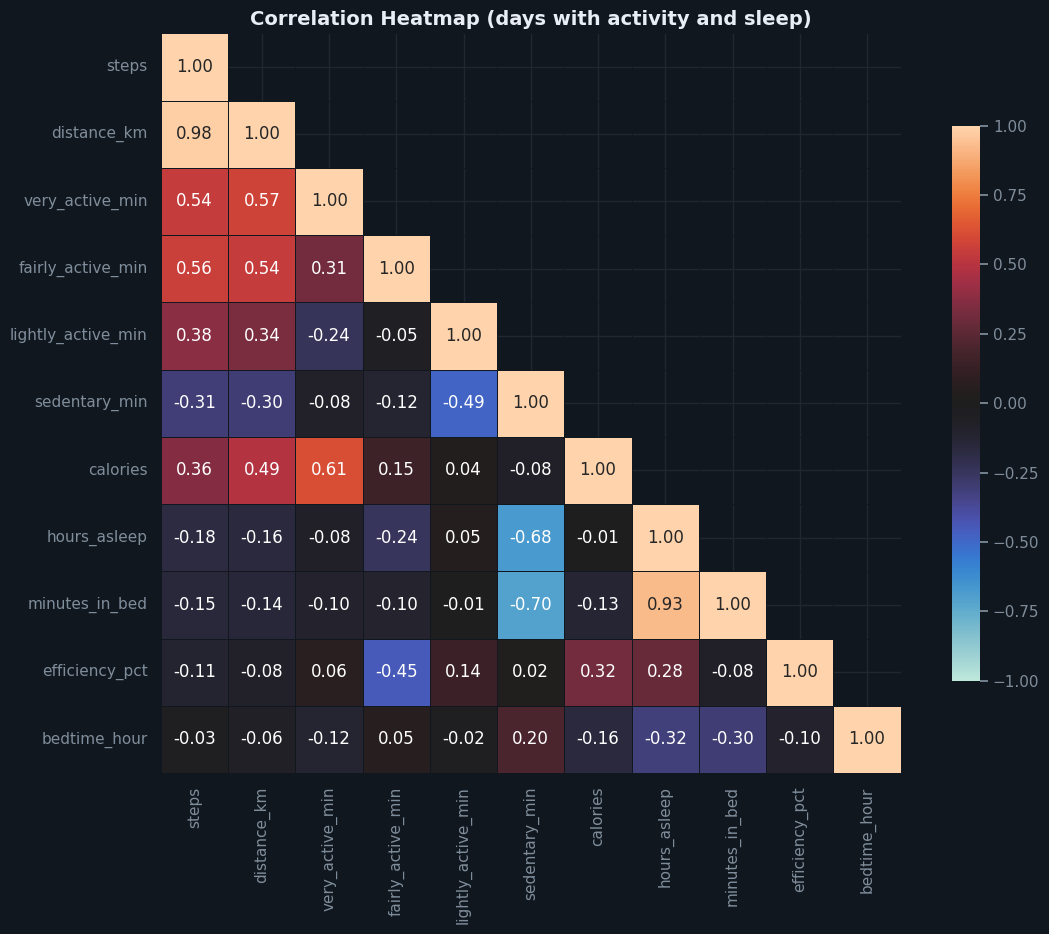

In [40]:
# Chart - 21 visualization code
cols = ["steps", "distance_km", "very_active_min", "fairly_active_min", "lightly_active_min", "sedentary_min",
        "calories", "hours_asleep", "minutes_in_bed", "efficiency_pct", "bedtime_hour"]
corr = daily_sleep[cols].corr()
fig, ax = plt.subplots(figsize=(12, 9.5))
sns.heatmap(corr, mask=np.triu(np.ones_like(corr, bool), 1), annot=True, fmt=".2f", cmap="icefire", center=0,
            vmin=-1, vmax=1, linewidths=0.6, linecolor=SURFACE, square=True, cbar_kws=dict(shrink=0.75), ax=ax)
ax.set_title("Correlation Heatmap (days with activity and sleep)")
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A lower-triangle correlation heatmap summarises every pairwise linear relationship, now including bedtime, in one compact view.

##### 2. What is/are the insight(s) found from the chart?

Steps and distance are almost the same (0.98). Very active minutes are the strongest activity link to calories. Sleep hours move with time in bed (0.93), against sedentary minutes (-0.68) and against bedtime (-0.32). Efficiency has little link to activity.

#### Chart - 22 - Pair Plot  *(Pair Plot)*

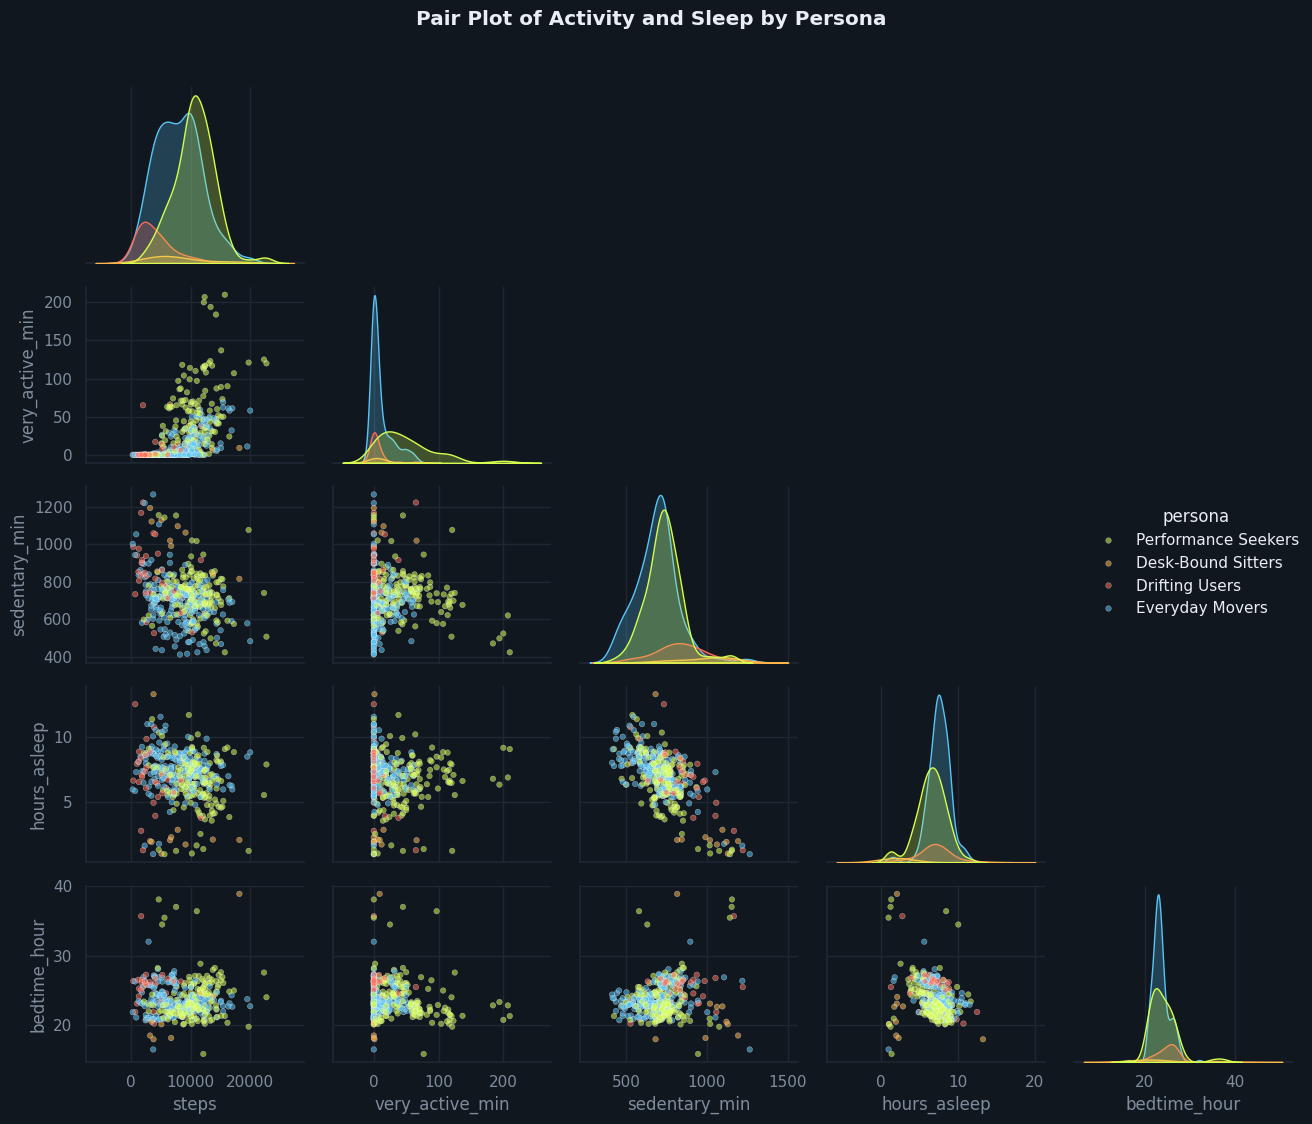

In [41]:
# Chart - 22 visualization code
pp = daily_sleep.merge(users[["user_id", "persona"]], on="user_id")
g = sns.pairplot(pp[["steps", "very_active_min", "sedentary_min", "hours_asleep", "bedtime_hour", "persona"]],
                 hue="persona", palette=PERSONA_COLORS, corner=True, height=2.2, plot_kws=dict(alpha=0.55, s=16))
g.figure.suptitle("Pair Plot of Activity and Sleep by Persona", y=1.02, fontweight="bold")
fig = g.figure
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

The pair plot shows every pairwise relationship and each variable's distribution, split by persona, in one grid. It checks whether the relationships hold within each group.

##### 2. What is/are the insight(s) found from the chart?

The personas separate most clearly on steps and very active minutes. The negative link between sitting and sleep appears in every persona, and late bedtimes go with shorter sleep across all groups.

### **Statistical validation of key findings**

In [42]:
# Hypothesis tests behind the main recommendations
sl = sleep.dropna(subset=["bedtime_hour"])
early, mid, late = (sl.loc[sl.bedtime_hour < 23, "hours_asleep"],
                    sl.loc[(sl.bedtime_hour >= 23) & (sl.bedtime_hour < 24.5), "hours_asleep"],
                    sl.loc[sl.bedtime_hour >= 24.5, "hours_asleep"])
tests = [
    ("Weekday vs weekend steps", "Welch t-test", *stats.ttest_ind(daily.loc[~daily.is_weekend, "steps"], daily.loc[daily.is_weekend, "steps"], equal_var=False)),
    ("Sleep across bedtime windows", "One-way ANOVA", *stats.f_oneway(early, mid, late)),
    ("Sitting vs sleep", "Pearson r", *stats.pearsonr(daily_sleep.sedentary_min, daily_sleep.hours_asleep)),
    ("Steps across personas", "Kruskal-Wallis", *stats.kruskal(*[g["avg_steps"] for _, g in users.groupby("persona")])),
    ("Very active min vs calories", "Pearson r", *stats.pearsonr(daily.very_active_min, daily.calories)),
]
res = pd.DataFrame(tests, columns=["hypothesis", "test", "statistic", "p_value"])
res["result"] = np.where(res.p_value < 0.05, "Significant", "Not significant")
res.round(4)

,hypothesis,test,statistic,p_value,result
0,Weekday vs weekend steps,Welch t-test,0.3144,0.7534,Not significant
1,Sleep across bedtime windows,One-way ANOVA,26.3684,0.0000,Significant
2,Sitting vs sleep,Pearson r,-0.6795,0.0000,Significant
3,Steps across personas,Kruskal-Wallis,24.5029,0.0000,Significant
4,Very active min vs calories,Pearson r,0.6172,0.0000,Significant


The tests confirm the recommendations. Bedtime, sitting time, persona differences and the intensity-calorie link are all significant. Weekend and weekday step totals are **not** significantly different, so weekend campaigns should focus on timing, not volume.

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

**Focus product:** the Bellabeat app with the Leaf tracker.

| # | Recommendation | Evidence | Impact / Effort |
|---|---|---|---|
| 1 | **Time-aware nudges:** move reminders timed to each user's weekday rhythm (5-7 PM) and weekend rhythm (12-2 PM) | Charts 8, 9, 18 | High / Low |
| 2 | **Bedtime coach:** 10:30 PM wind-down reminder and a weekly bedtime consistency score | Charts 3, 12; ANOVA p < 0.001 | High / Medium |
| 3 | **"Sit less, sleep better" campaign** that links daytime movement to that night's sleep on one screen | Charts 13, 21; r = -0.68 | High / Low |
| 4 | **15-minute intensity sessions** marketed as the most efficient route to results ("20 minutes = about 250 kcal") | Charts 10, 11, 14 | Medium / Medium |
| 5 | **Persona journeys:** performance plans for Seekers, desk-break programs for Sitters, win-back flows for Drifting Users | Charts 19, 20; Kruskal-Wallis p < 0.01 | High / High |
| 6 | **Zero-effort tracking and habit protection:** 24/7 comfort, auto-sync with a smart scale, streaks from week 2 | Charts 5, 15, 16, 17 | Medium / High |

**90-day plan:** launch 1 and 3 as quick wins, build 2 and 4 in the second month with A/B tests on reminder timing, then roll out 5 and 6.
**Success metrics:** week-4 wear retention (baseline -17%), sleep-tracking adoption (baseline 73%), share of users meeting 150 MVPA minutes a week (baseline 58%) and share of nights of 7 hours or more (baseline 55%).

# **Conclusion**

Building a proper SQL warehouse on all 18 files, instead of only the daily summaries, revealed patterns a basic analysis would miss. People move at predictable times, but most of their tracked day is sedentary. Intensity, not step volume, drives energy burn. Short sleep is mainly caused by going to bed late, not by restless nights. Engagement fades gradually, and it fades fastest among the least active users, who would benefit most. K-Means clustering turned 33 individuals into four personas that are statistically distinct, and each needs a different message.

For Bellabeat, the opportunity is to market the app and Leaf as a wellness coach that fits into the user's day. That means well-timed nudges, a bedtime routine, a clear link between movement and sleep, short effective workouts, and tracking that needs no effort.

**Limitations:** 33 users with no confirmed gender (Bellabeat targets women), no age data, one month of 2016 data, and sleep minutes that affect sedentary totals. **Next steps:** repeat the pipeline on Bellabeat's own data, add demographics, and A/B test the recommended nudge timings.

### ***Hurrah! You have successfully completed your EDA Capstone Project !!!***